# Hospital Readmission Prediction using Machine Learning

## 1. Introduction

Hospital readmission is one of the most important quality indicators in healthcare systems worldwide. Patients who are readmitted shortly after discharge often experience poor health outcomes, increased treatment costs, and greater pressure on hospital resources. Predicting the likelihood of readmission enables healthcare providers to identify high-risk patients early and implement preventive interventions before discharge.

This module focuses on developing a machine learning-based hospital readmission prediction system using a real-world synthetic healthcare dataset containing patient demographics, hospital admissions, diagnoses, laboratory values, billing information, and hospital characteristics.

Unlike traditional single-table datasets, this dataset consists of multiple relational tables that must be integrated before analysis. Therefore, the first stage of this module involves data integration to create a comprehensive master dataset suitable for machine learning.

The final objective is to predict whether a patient will be readmitted within 30 days after discharge by utilizing demographic information, clinical measurements, previous medical history, hospital characteristics, and diagnosis information.

## 2. Objectives

The objectives of this module are:

- Load all healthcare datasets.
- Understand the structure of each dataset.
- Merge multiple relational tables into a single master dataset.
- Perform exploratory data analysis.
- Clean and preprocess the data.
- Engineer meaningful predictive features.
- Train multiple machine learning algorithms.
- Compare baseline and tuned models.
- Explain model predictions using SHAP.
- Develop a hospital readmission prediction system.

## 3. Dataset Description

The dataset consists of five interconnected healthcare tables.

### Patients
Contains demographic information such as age, gender, insurance type, previous admissions, and comorbidity count.

### Admissions
Contains hospitalization details including admission type, discharge information, laboratory values, procedures, and readmission labels.

### Diagnoses
Contains ICD-10 diagnosis codes assigned during each admission.

### Billing
Contains hospital expenditure and payment-related information.

### Hospitals
Contains hospital characteristics including location, hospital tier, number of beds, and teaching status.

The prediction target for this study is:

**readmitted_30d**

where:

- 0 = No Readmission
- 1 = Readmitted within 30 Days

## 4. IMPORT LIBRARIES

In [1]:
# ==========================================================
# 4. IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 5. LOAD DATASETS

In [2]:
# ==========================================================
# 5. LOAD DATASETS
# ==========================================================

import pandas as pd

# Load all project datasets
patients = pd.read_csv(r"patients.csv")
admissions = pd.read_csv(r"admissions.csv")
diagnoses = pd.read_csv(r"diagnoses.csv")
billing = pd.read_csv(r"billing.csv")
hospitals = pd.read_csv(r"hospitals.csv")

print("=" * 70)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 70)

print("Patients   :", patients.shape)
print("Admissions :", admissions.shape)
print("Diagnoses  :", diagnoses.shape)
print("Billing    :", billing.shape)
print("Hospitals  :", hospitals.shape)

DATASETS LOADED SUCCESSFULLY
Patients   : (86400, 8)
Admissions : (120000, 17)
Diagnoses  : (271341, 6)
Billing    : (120000, 6)
Hospitals  : (33, 6)


## 6. DATASET OVERVIEW

In [3]:
# ==========================================================
# 6. DATASET OVERVIEW
# ==========================================================

datasets = {
    "Patients": patients,
    "Admissions": admissions,
    "Diagnoses": diagnoses,
    "Billing": billing,
    "Hospitals": hospitals
}

for name, df in datasets.items():

    print("="*80)
    print(name.upper())
    print("="*80)

    print("Shape :", df.shape)

    display(df.head())

    print(df.info())

PATIENTS
Shape : (86400, 8)


,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         86400 non-null  object
 1   age                86400 non-null  int64 
 2   gender             86400 non-null  object
 3   state              86400 non-null  object
 4   bpl_card           86400 non-null  bool  
 5   insurance_type     61685 non-null  object
 6   comorbidity_count  86400 non-null  int64 
 7   prev_admissions    86400 non-null  int64 
dtypes: bool(1), int64(3), object(4)
memory usage: 4.7+ MB
None
ADMISSIONS
Shape : (120000, 17)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   admission_id    120000 non-null  object 
 1   patient_id      120000 non-null  object 
 2   admit_date      120000 non-null  object 
 3   discharge_date  120000 non-null  object 
 4   los_days        120000 non-null  int64  
 5   admit_type      120000 non-null  object 
 6   ward_type       120000 non-null  object 
 7   hospital_id     120000 non-null  object 
 8   discharge_type  120000 non-null  object 
 9   num_procedures  120000 non-null  int64  
 10  charlson_index  120000 non-null  int64  
 11  hba1c           120000 non-null  float64
 12  creatinine      120000 non-null  float64
 13  haemoglobin     120000 non-null  float64
 14  systolic_bp     120000 non-null  int64  
 15  readmitted_30d  120000 non-null  int64  
 16  readmitted_7d   120000 non-null  int64  
dtypes: float64

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271341 entries, 0 to 271340
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   diag_id        271341 non-null  object
 1   admission_id   271341 non-null  object
 2   icd10_code     271341 non-null  object
 3   diag_desc      271341 non-null  object
 4   diag_rank      271341 non-null  int64 
 5   diag_category  271341 non-null  object
dtypes: int64(1), object(5)
memory usage: 12.4+ MB
None
BILLING
Shape : (120000, 6)


,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room
3,32f41176-c088-4e9a-aa81-ae40f91b912a,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,72588,0,72588,Lab
4,cf80fba9-7fec-4b2e-b548-037a43dcf93c,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,9510,0,9510,Lab


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   bill_id            120000 non-null  object
 1   admission_id       120000 non-null  object
 2   total_cost_inr     120000 non-null  int64 
 3   govt_subsidy_inr   120000 non-null  int64 
 4   out_of_pocket_inr  120000 non-null  int64 
 5   cost_category      120000 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.5+ MB
None
HOSPITALS
Shape : (33, 6)


,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hospital_id  33 non-null     object
 1   name         33 non-null     object
 2   state        33 non-null     object
 3   tier         33 non-null     object
 4   beds         33 non-null     int64 
 5   teaching     33 non-null     bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 1.4+ KB
None


# 7. Data integration
## 7.1 Diagnosis Aggregation

Since one admission may contain multiple diagnosis records, the diagnosis table is first aggregated so that each admission corresponds to a single row. This prevents duplication during dataset merging and preserves essential diagnosis information for predictive modeling.

In [4]:
# ==========================================================
# 7.1 AGGREGATE DIAGNOSES
# ==========================================================

diagnosis_summary = (

    diagnoses

    .groupby("admission_id")

    .agg(

        diagnosis_count=("diag_id", "count"),

        primary_diagnosis=("diag_desc", "first"),

        primary_category=("diag_category", "first")

    )

    .reset_index()

)

print(diagnosis_summary.shape)

diagnosis_summary.head()

(120000, 4)


,admission_id,diagnosis_count,primary_diagnosis,primary_category
0,0001273a-4e21-47f3-8dff-877734fb010c,1,Malignant neoplasm — breast,Neoplasm
1,00020220-ca07-4b22-bed3-934e565d2875,1,Maternal care — uterine anomaly,Obstetric
2,0003b202-ff44-43ac-bc52-6075f4ecddf9,3,Type 1 diabetes mellitus,Endocrine
3,0004897e-6c81-44ed-bc91-b9ae47bedced,3,Epilepsy,Neurological
4,000616dc-80eb-4a95-a8cd-60245916a9a9,3,Respiratory distress — newborn,Perinatal


## 7.2 Merge Patient and Admission Information

Patient demographic information is merged with hospital admission records using the patient identifier.

In [5]:
master_df = admissions.merge(

    patients,

    on="patient_id",

    how="left"

)

print(master_df.shape)

(120000, 24)


## 7.3 Merge Billing Information

Hospital billing information is merged using the admission identifier.

In [6]:
master_df = master_df.merge(

    billing,

    on="admission_id",

    how="left"

)

print(master_df.shape)

(120000, 29)


## 7.4 Merge Hospital Information

Hospital characteristics are merged using the hospital identifier.

In [7]:
master_df = master_df.merge(

    hospitals,

    on="hospital_id",

    how="left",

    suffixes=("","_hospital")

)

print(master_df.shape)

(120000, 34)


## 7.5 Merge Diagnosis Information

The aggregated diagnosis summary is merged with the master dataset using the admission identifier.

In [8]:
master_df = master_df.merge(

    diagnosis_summary,

    on="admission_id",

    how="left"

)

print(master_df.shape)

(120000, 37)


## 7.6 Verify Master Dataset

The final master dataset is inspected to verify that all tables have been successfully integrated.

In [9]:
# ==========================================================
# FINAL MASTER DATASET
# ==========================================================

print("="*80)
print("MASTER DATASET")
print("="*80)

print("Shape :", master_df.shape)

display(master_df.head())

print(master_df.info())

MASTER DATASET
Shape : (120000, 37)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,bill_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,name,state_hospital,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,68e19242-4126-4a7a-afa2-9e6035cdcffa,18492,16630,1862,Lab,Government General Hospital Odisha,Odisha,tier2,359,True,1,Metabolic / electrolyte disorder,Endocrine
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0,b740202e-1d7a-45b4-9575-21b35e219e37,1001,0,1001,Lab,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,1,Asthma,Respiratory
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,f60fecaa-e769-42ea-bee8-58198bdd1208,59696,48650,11046,Room,Apollo/Manipal (Private) Karnataka,Karnataka,tier1,1018,True,3,Epilepsy,Neurological
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0,56,F,Kerala,False,NaN,0,1,32f41176-c088-4e9a-aa81-ae40f91b912a,72588,0,72588,Lab,District Hospital Uttar Pradesh,Uttar Pradesh,tier3,191,False,1,Heart failure,Cardiovascular
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0,69,F,Kerala,False,NaN,2,0,cf80fba9-7fec-4b2e-b548-037a43dcf93c,9510,0,9510,Lab,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,3,Malignant neoplasm — breast,Neoplasm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   admission_id       120000 non-null  object 
 1   patient_id         120000 non-null  object 
 2   admit_date         120000 non-null  object 
 3   discharge_date     120000 non-null  object 
 4   los_days           120000 non-null  int64  
 5   admit_type         120000 non-null  object 
 6   ward_type          120000 non-null  object 
 7   hospital_id        120000 non-null  object 
 8   discharge_type     120000 non-null  object 
 9   num_procedures     120000 non-null  int64  
 10  charlson_index     120000 non-null  int64  
 11  hba1c              120000 non-null  float64
 12  creatinine         120000 non-null  float64
 13  haemoglobin        120000 non-null  float64
 14  systolic_bp        120000 non-null  int64  
 15  readmitted_30d     120000 non-null  int64  
 16  re

# 8. Exploratory Data Analysis (EDA)
## 8.1 Dataset Summary

After integrating all relational tables, the resulting master dataset contains patient demographics, hospital admission details, diagnosis information, laboratory measurements, billing information, and hospital characteristics.

The objective of this exploratory data analysis is to understand the overall structure of the dataset, identify potential data quality issues, analyze feature distributions, and explore relationships between variables before preprocessing and model development.

In [10]:
# ==========================================================
# 8.1 DATASET SUMMARY
# ==========================================================

print("="*80)
print("MASTER DATASET SUMMARY")
print("="*80)

print(f"Rows    : {master_df.shape[0]}")
print(f"Columns : {master_df.shape[1]}")

print("\nColumn Names\n")
print(master_df.columns.tolist())

print("\nData Types\n")
display(master_df.dtypes.to_frame("Data Type"))

MASTER DATASET SUMMARY
Rows    : 120000
Columns : 37

Column Names

['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d', 'age', 'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count', 'prev_admissions', 'bill_id', 'total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr', 'cost_category', 'name', 'state_hospital', 'tier', 'beds', 'teaching', 'diagnosis_count', 'primary_diagnosis', 'primary_category']

Data Types



,Data Type
admission_id,object
patient_id,object
admit_date,object
discharge_date,object
los_days,int64
admit_type,object
ward_type,object
hospital_id,object
discharge_type,object
num_procedures,int64


## 8.2 Missing Value Analysis

Missing value analysis is performed to identify incomplete observations that may influence model performance. Features with missing values will be handled during the preprocessing stage using appropriate imputation techniques.

MISSING VALUE ANALYSIS


,Missing Values,Percentage
insurance_type,33987,28.32
patient_id,0,0.00
admit_date,0,0.00
discharge_date,0,0.00
admission_id,0,0.00
los_days,0,0.00
admit_type,0,0.00
hospital_id,0,0.00
ward_type,0,0.00
num_procedures,0,0.00


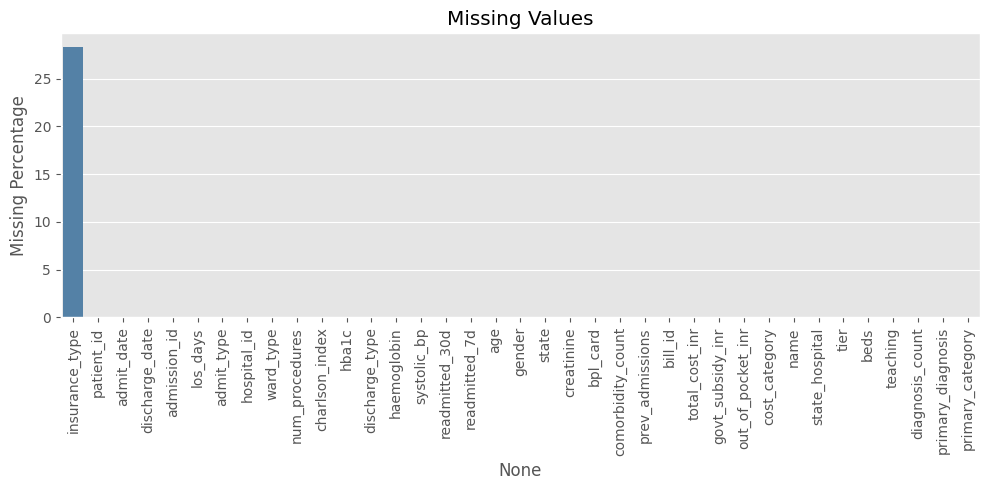

In [11]:
# ==========================================================
# 8.2 MISSING VALUES
# ==========================================================

missing = pd.DataFrame({
    "Missing Values": master_df.isnull().sum(),
    "Percentage": round(master_df.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

print("="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

display(missing)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"],
    color="steelblue"
)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage")

plt.title("Missing Values")

plt.tight_layout()

plt.show()

## 8.3 Duplicate Record Analysis

Duplicate observations may introduce bias during model training. Therefore, duplicate records are identified to determine whether removal is required.

In [12]:
# ==========================================================
# 8.3 DUPLICATES
# ==========================================================

duplicates = master_df.duplicated().sum()

print("="*80)
print("DUPLICATE RECORD ANALYSIS")
print("="*80)

print("Duplicate Records :", duplicates)

print(
    "Duplicate Percentage :",
    round((duplicates/len(master_df))*100,2),
    "%"
)

DUPLICATE RECORD ANALYSIS
Duplicate Records : 0
Duplicate Percentage : 0.0 %


## 8.4 Readmission Distribution

The target variable represents whether a patient was readmitted within 30 days following discharge. Understanding the distribution of the target classes is essential for identifying class imbalance prior to model development.

READMISSION DISTRIBUTION


,Count,Percentage
readmitted_30d,,
0,105790,88.16
1,14210,11.84


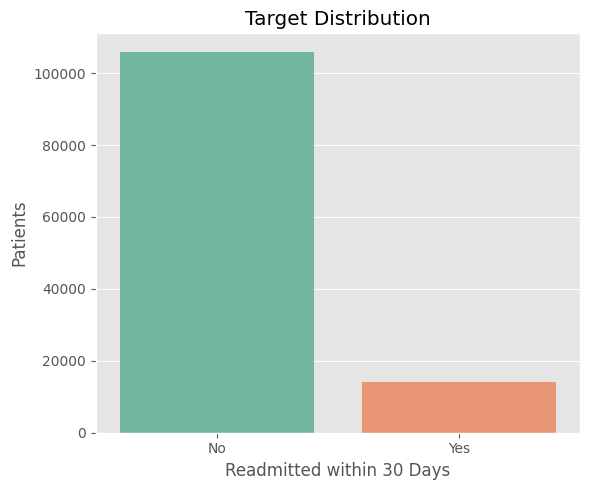

In [13]:
# ==========================================================
# 8.4 TARGET DISTRIBUTION
# ==========================================================

target = master_df["readmitted_30d"].value_counts()

target_df = pd.DataFrame({

    "Count":target,

    "Percentage":round(
        target/len(master_df)*100,
        2
    )

})

print("="*80)
print("READMISSION DISTRIBUTION")
print("="*80)

display(target_df)

plt.figure(figsize=(6,5))

sns.countplot(
    data=master_df,
    x="readmitted_30d",
    palette="Set2"
)

plt.xticks([0,1],["No","Yes"])

plt.xlabel("Readmitted within 30 Days")

plt.ylabel("Patients")

plt.title("Target Distribution")

plt.tight_layout()

plt.show()

## 8.5 Distribution of Categorical Variables

This section visualizes the distribution of important categorical variables in the dataset.

Since some variables contain a large number of unique categories, only the top 10 most frequent categories are displayed for better visualization.

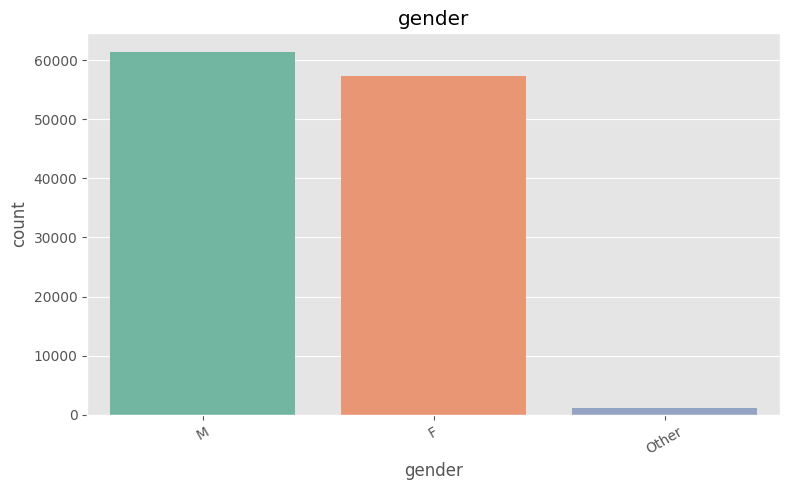

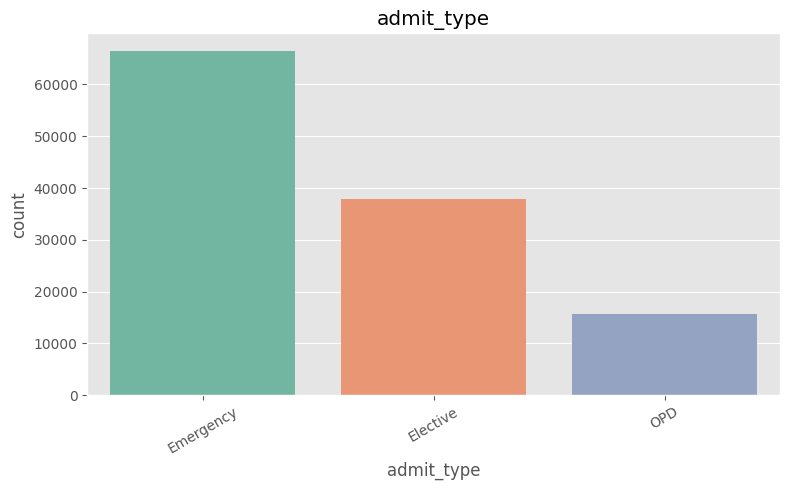

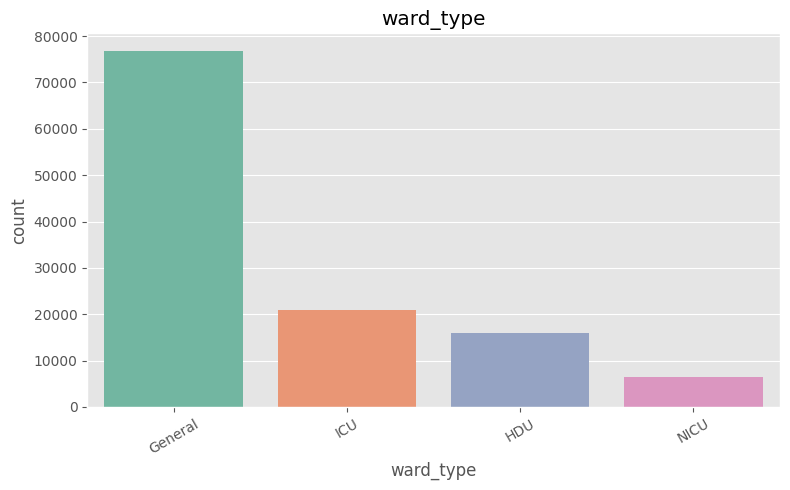

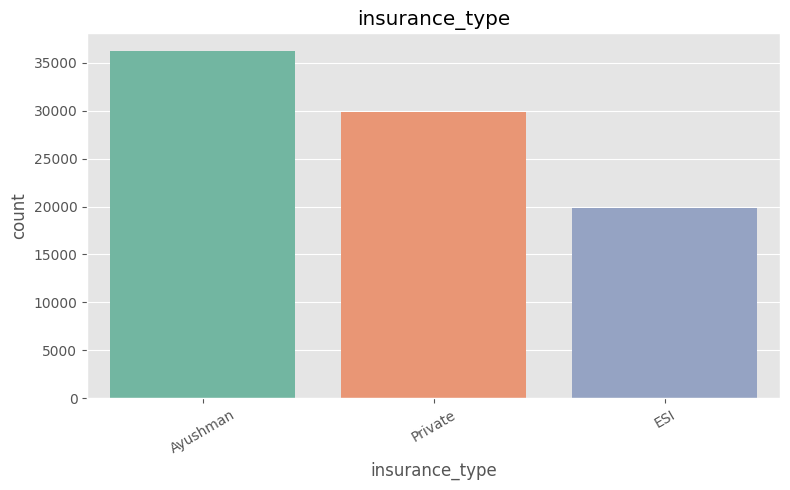

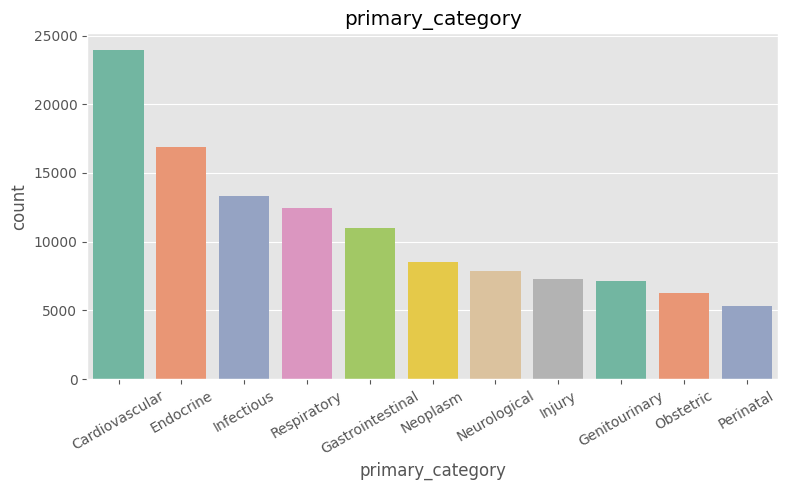

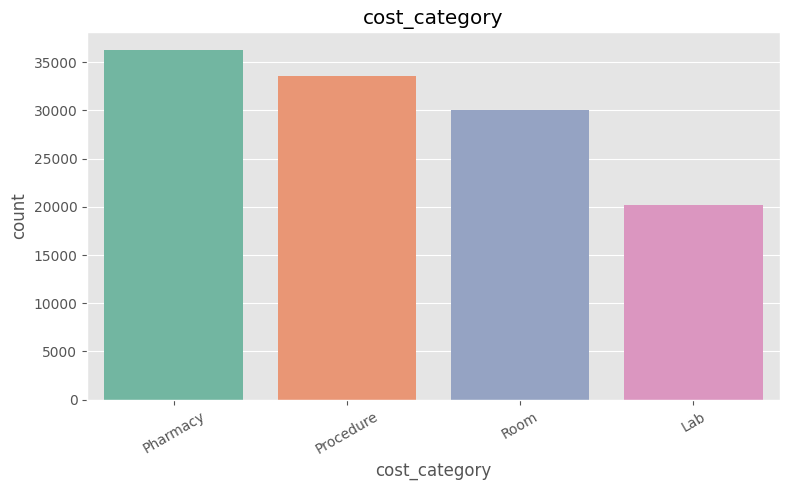

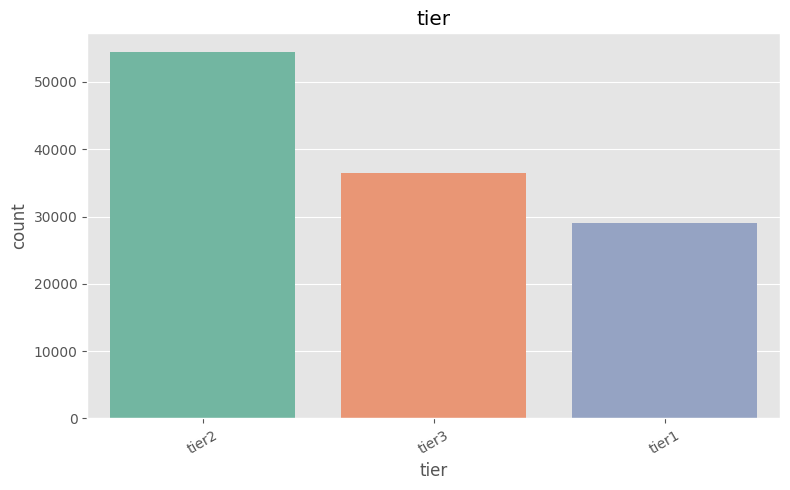

In [14]:
# ==========================================================
# 8.5 Distribution of Important Categorical Features
# ==========================================================

categorical_features = [
    "gender",
    "admit_type",
    "ward_type",
    "insurance_type",
    "primary_category",
    "cost_category",
    "tier"
]

for feature in categorical_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=master_df,
        x=feature,
        order=master_df[feature].value_counts().index,
        palette="Set2"
    )

    plt.title(feature)

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

## 8.6 Top 10 Primary Diagnoses

The primary diagnosis variable contains numerous disease names. Therefore, only the ten most frequently occurring diagnoses are visualized to improve readability.

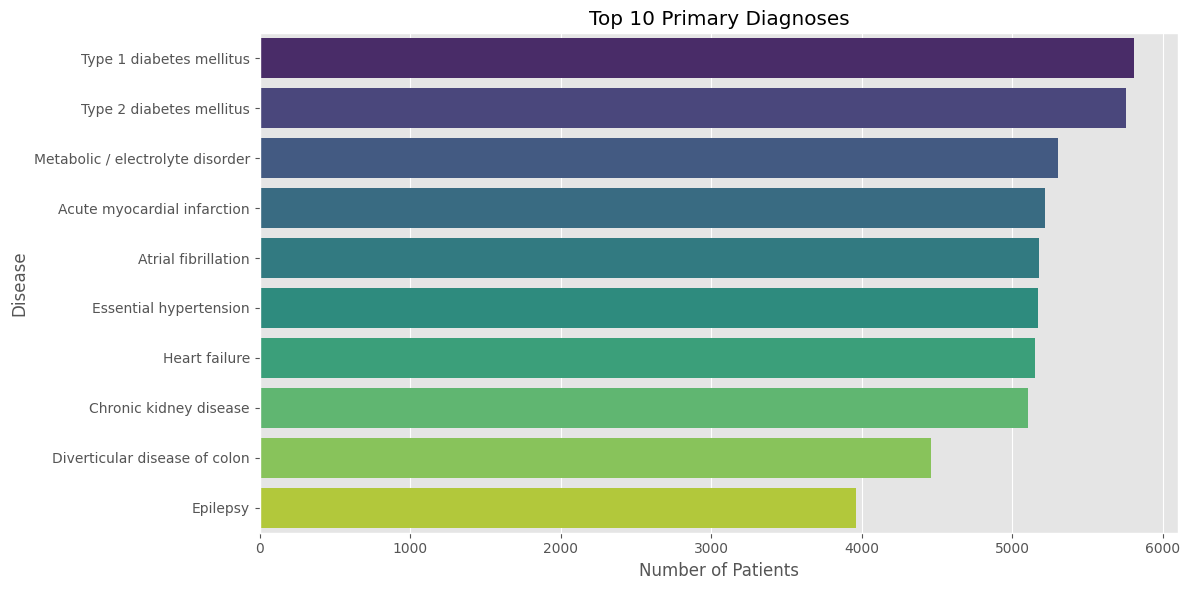

In [15]:
# ==========================================================
# Top 10 Diseases
# ==========================================================

top10 = master_df["primary_diagnosis"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="viridis"
)

plt.title("Top 10 Primary Diagnoses")

plt.xlabel("Number of Patients")

plt.ylabel("Disease")

plt.tight_layout()

plt.show()

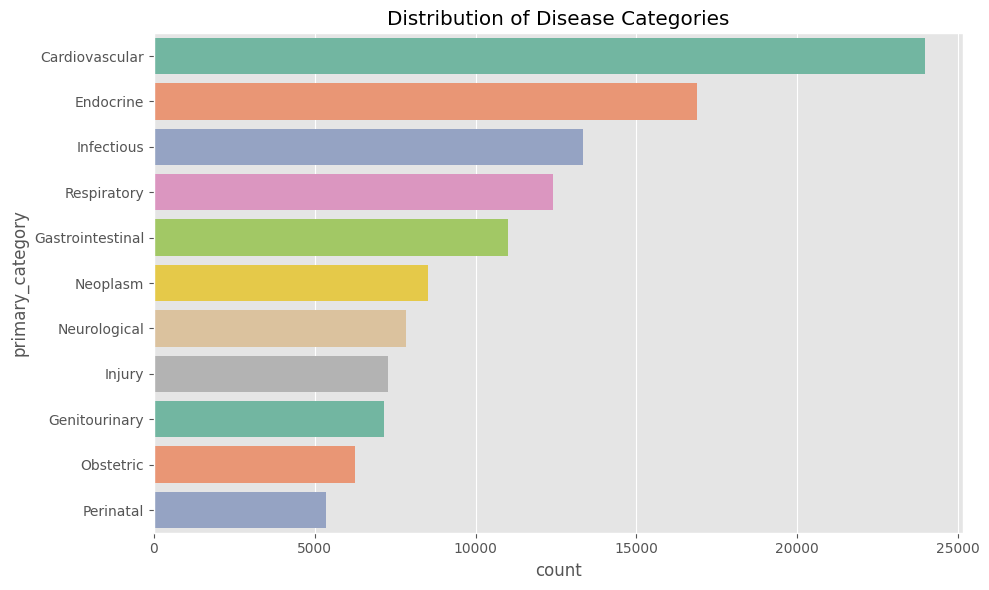

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=master_df,
    y="primary_category",
    order=master_df["primary_category"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Disease Categories")

plt.tight_layout()

plt.show()

## 8.7 Relationship Between Categorical Features and 30-Day Readmission

This section examines the relationship between important categorical variables and the 30-day hospital readmission status.

Stacked bar charts are used to compare the proportion of patients who were readmitted and not readmitted across different categories.

<Figure size 900x500 with 0 Axes>

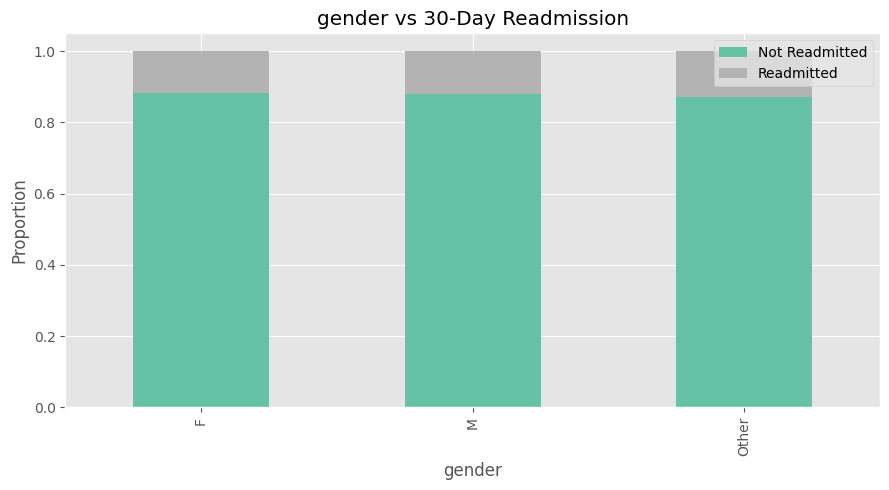

<Figure size 900x500 with 0 Axes>

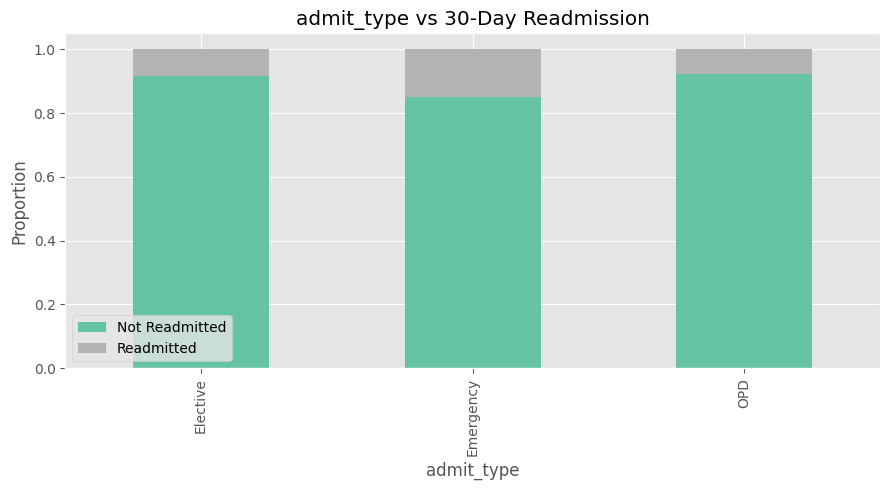

<Figure size 900x500 with 0 Axes>

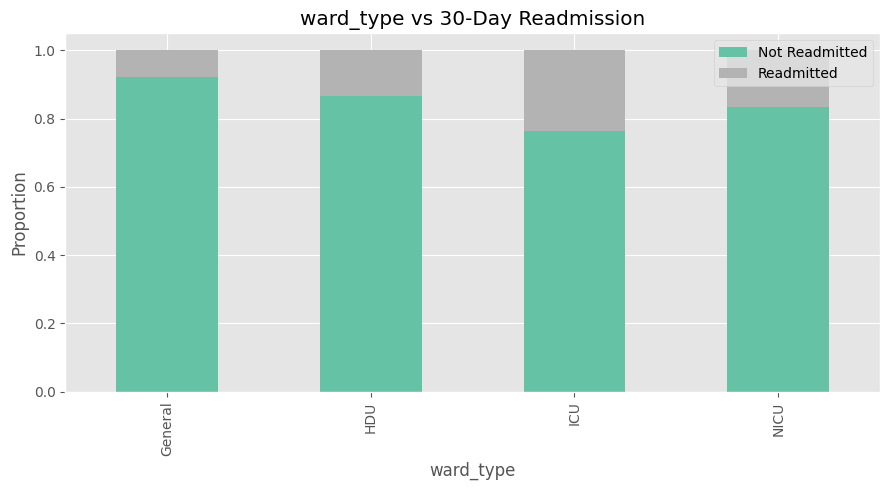

<Figure size 900x500 with 0 Axes>

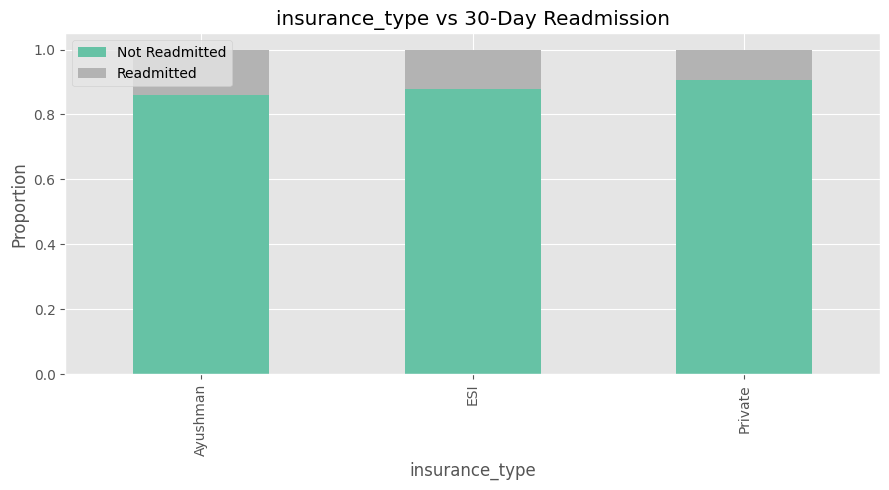

<Figure size 900x500 with 0 Axes>

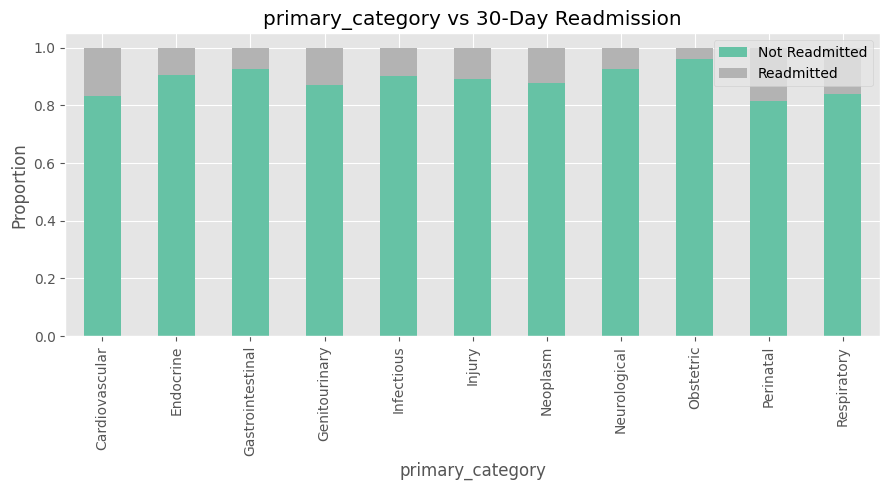

In [17]:
# ==========================================================
# 8.7 Categorical Features vs Readmission
# ==========================================================

categorical_features = [
    "gender",
    "admit_type",
    "ward_type",
    "insurance_type",
    "primary_category"
]

for feature in categorical_features:

    plt.figure(figsize=(9,5))

    pd.crosstab(
        master_df[feature],
        master_df["readmitted_30d"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        figsize=(9,5),
        colormap="Set2"
    )

    plt.title(f"{feature} vs 30-Day Readmission")
    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.legend(["Not Readmitted","Readmitted"])

    plt.tight_layout()
    plt.show()

## 8.8 Distribution of Continuous Variables by Readmission Status

This section compares the distribution of important numerical variables between patients who were readmitted within 30 days and those who were not.

Boxplots help identify differences in central tendency, spread, and potential outliers.

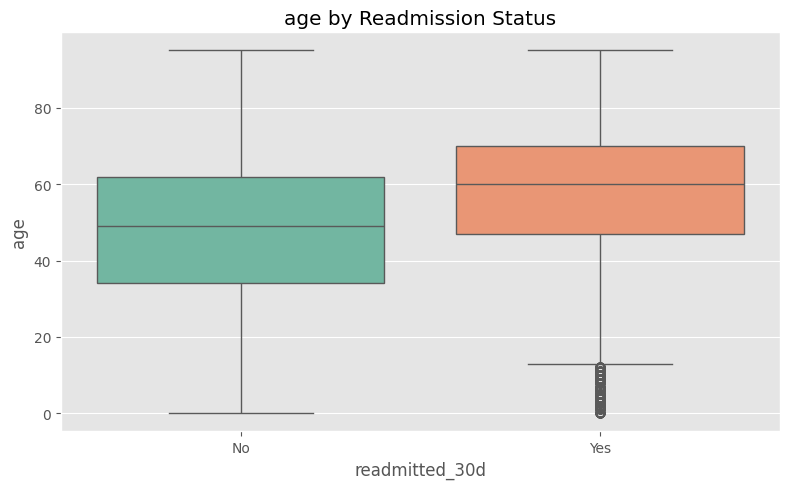

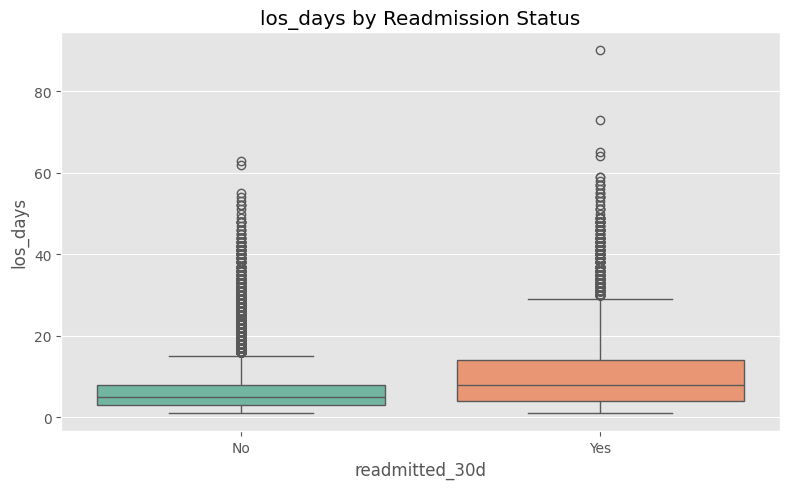

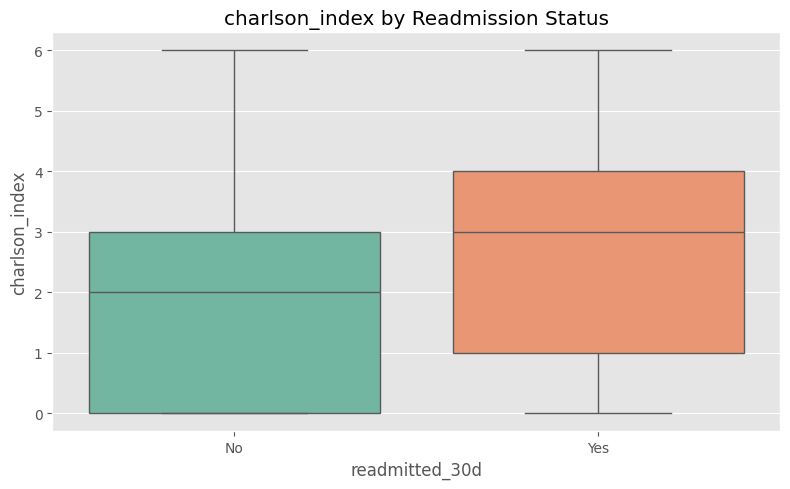

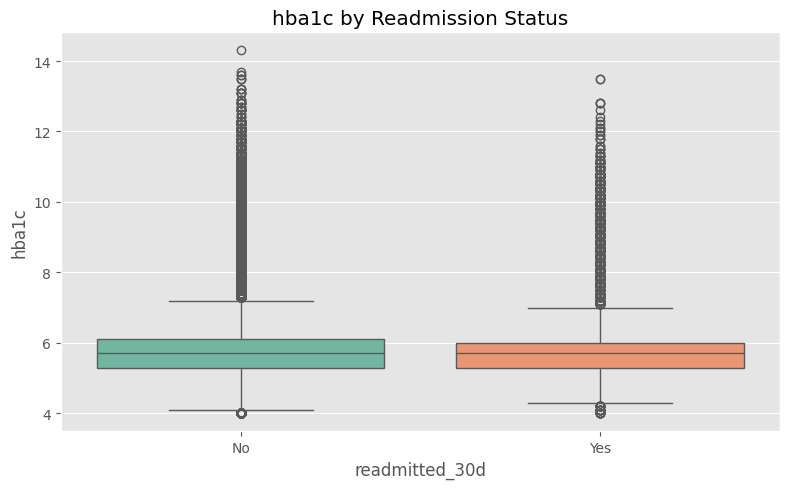

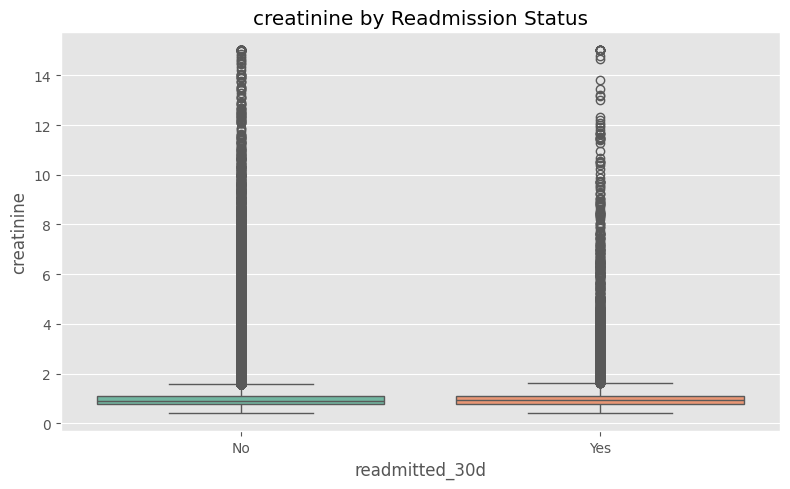

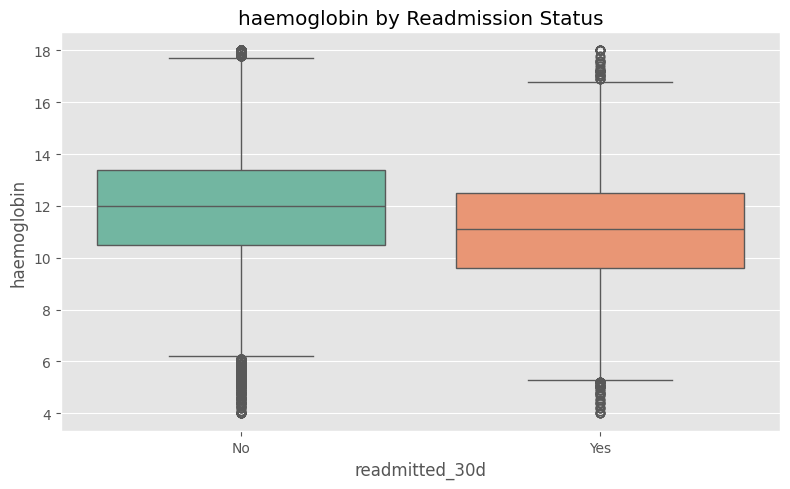

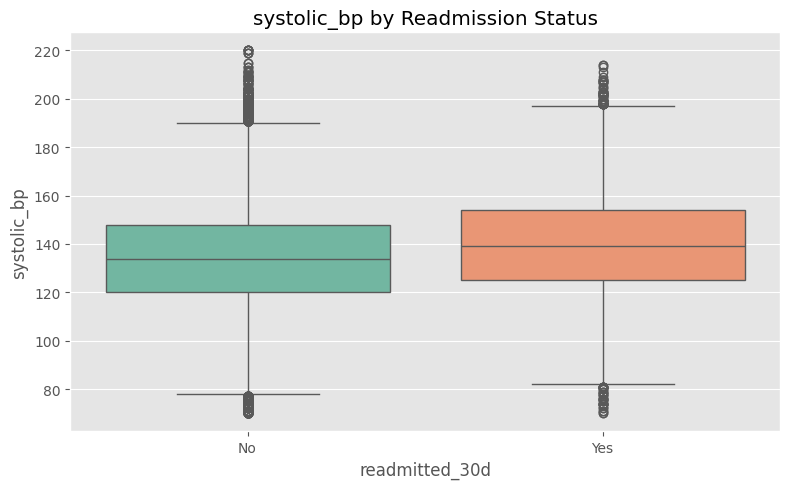

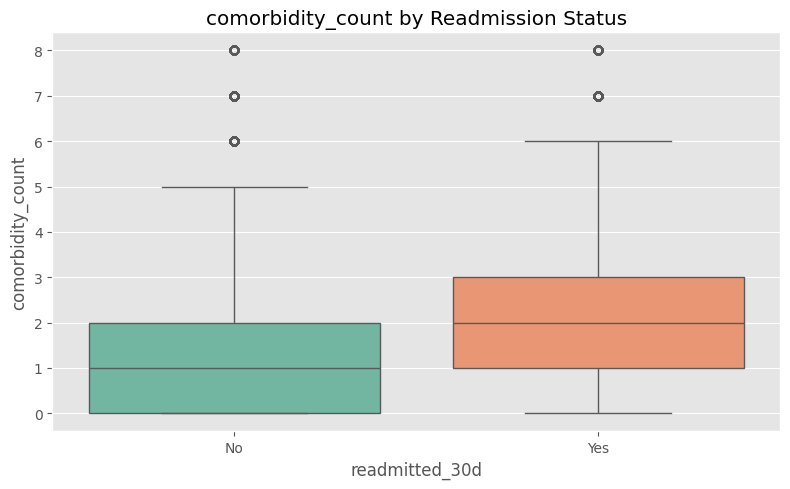

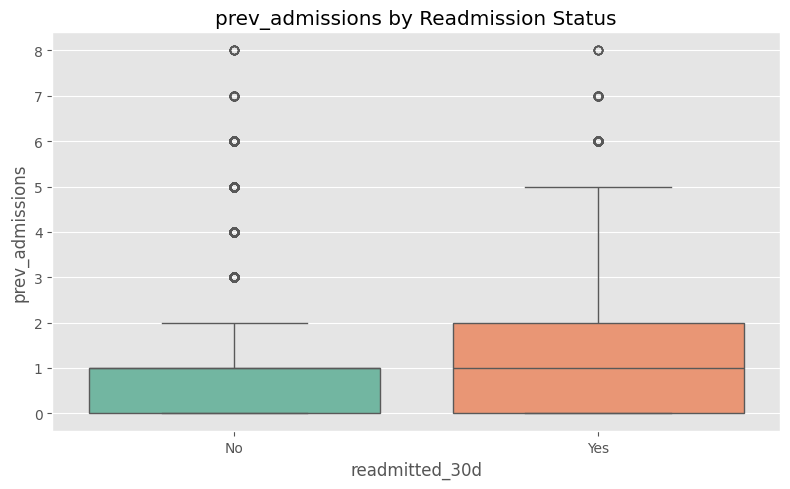

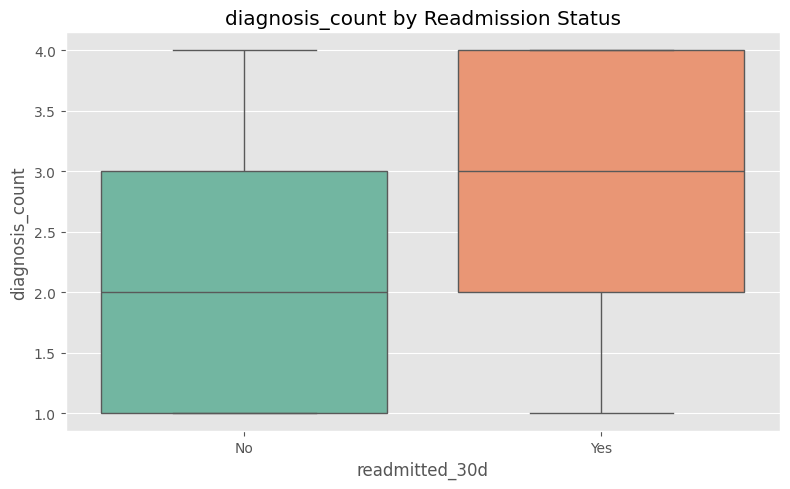

In [18]:
# ==========================================================
# 8.8 Continuous Features vs Readmission
# ==========================================================

continuous_features = [
    "age",
    "los_days",
    "charlson_index",
    "hba1c",
    "creatinine",
    "haemoglobin",
    "systolic_bp",
    "comorbidity_count",
    "prev_admissions",
    "diagnosis_count"
]

for feature in continuous_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=master_df,
        x="readmitted_30d",
        y=feature,
        palette="Set2"
    )

    plt.title(f"{feature} by Readmission Status")

    plt.xticks([0,1],["No","Yes"])

    plt.tight_layout()

    plt.show()

## 8.9 Correlation Analysis

Pearson correlation analysis is performed on numerical variables to identify relationships among clinical measurements and hospital-related factors.

The correlation heatmap helps detect multicollinearity and understand associations between variables.

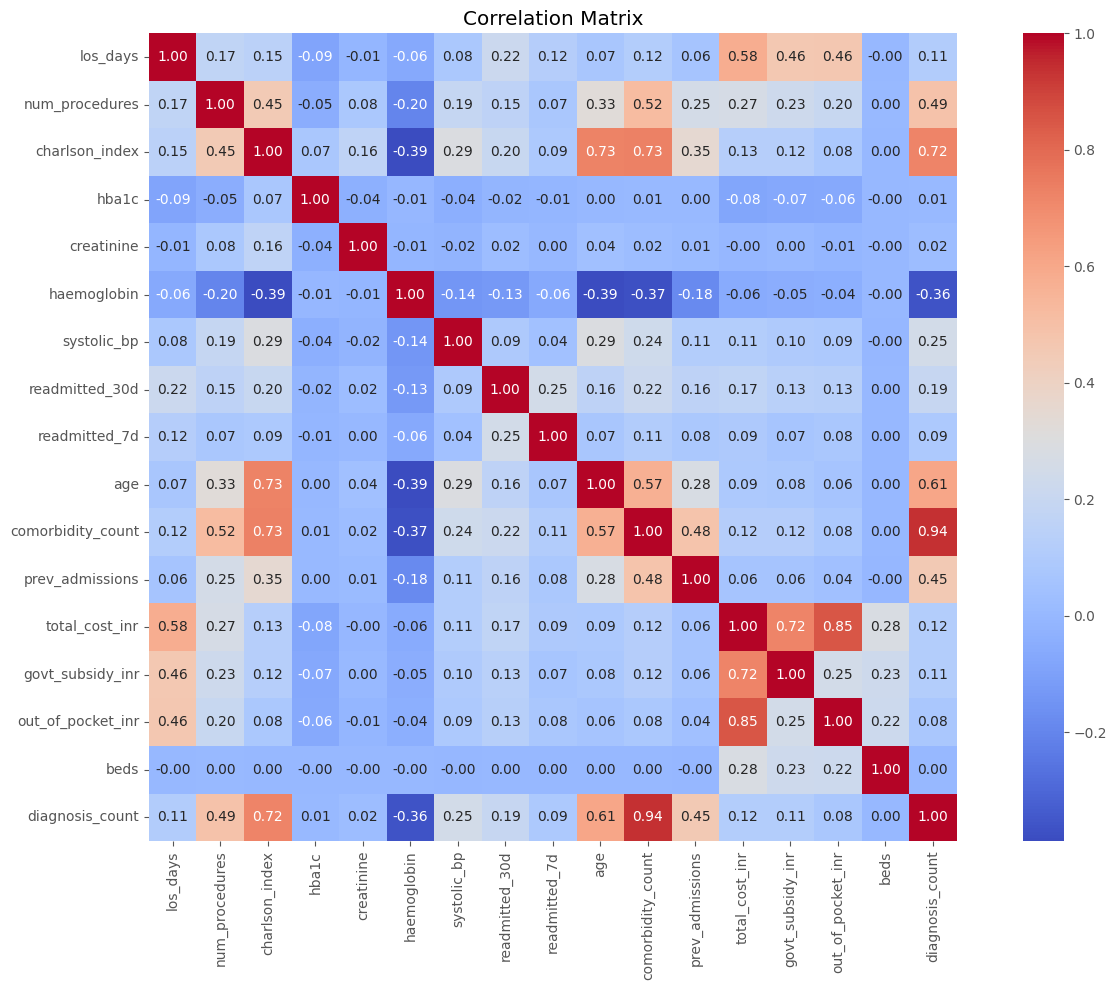

Correlation Matrix


,los_days,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,beds,diagnosis_count
los_days,1.000000,0.167297,0.145957,-0.085518,-0.012357,-0.063159,0.080877,0.218204,0.119882,0.069282,0.115214,0.059319,0.582470,0.462648,0.463838,-0.001621,0.108465
num_procedures,0.167297,1.000000,0.447379,-0.047991,0.083928,-0.197794,0.187226,0.154993,0.073911,0.325192,0.519477,0.252191,0.268368,0.229544,0.201237,0.004676,0.489129
charlson_index,0.145957,0.447379,1.000000,0.074738,0.160879,-0.387260,0.293626,0.199160,0.086483,0.728092,0.730800,0.354877,0.125683,0.123798,0.081838,0.000987,0.719122
hba1c,-0.085518,-0.047991,0.074738,1.000000,-0.040040,-0.005454,-0.044924,-0.015158,-0.010071,0.001088,0.006544,0.003140,-0.082671,-0.068279,-0.063843,-0.001877,0.006333
creatinine,-0.012357,0.083928,0.160879,-0.040040,1.000000,-0.010326,-0.018887,0.021083,0.002468,0.037435,0.019719,0.010461,-0.004310,0.003503,-0.008705,-0.001896,0.021562
haemoglobin,-0.063159,-0.197794,-0.387260,-0.005454,-0.010326,1.000000,-0.139604,-0.131524,-0.063473,-0.385072,-0.371489,-0.182750,-0.058753,-0.050079,-0.044189,-0.002508,-0.360392
systolic_bp,0.080877,0.187226,0.293626,-0.044924,-0.018887,-0.139604,1.000000,0.090246,0.043299,0.290683,0.235881,0.111607,0.114658,0.096129,0.087456,-0.004835,0.250730
readmitted_30d,0.218204,0.154993,0.199160,-0.015158,0.021083,-0.131524,0.090246,1.000000,0.250878,0.156359,0.217649,0.158402,0.167046,0.134149,0.131907,0.002330,0.192953
readmitted_7d,0.119882,0.073911,0.086483,-0.010071,0.002468,-0.063473,0.043299,0.250878,1.000000,0.068673,0.108300,0.082584,0.092260,0.066794,0.078408,0.001467,0.086955
age,0.069282,0.325192,0.728092,0.001088,0.037435,-0.385072,0.290683,0.156359,0.068673,1.000000,0.569032,0.277830,0.087141,0.078954,0.061979,0.001608,0.606546


In [19]:
# ==========================================================
# 8.9 Correlation Matrix
# ==========================================================

numerical_columns = master_df.select_dtypes(include=["int64","float64"]).columns

corr = master_df[numerical_columns].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

print("="*80)
print("Correlation Matrix")
print("="*80)

corr

## 8.10 Key Insights from Exploratory Data Analysis

Major findings obtained from exploratory data analysis include:

- The dataset contains 120,000 hospital admissions collected from hospitals across India.
- Only the `insurance_type` feature contains missing values (approximately 28%), while all remaining variables are complete.
- No duplicate records were identified.
- The dataset is imbalanced, with approximately 88% non-readmitted patients and 12% readmitted patients.
- Clinical variables such as Charlson Index, HbA1c, Creatinine, Length of Stay, and Previous Admissions show noticeable variation between readmitted and non-readmitted patients.
- Cardiovascular, Respiratory, Endocrine, and Neurological diseases constitute a substantial proportion of admissions.
- The correlation analysis indicates low to moderate correlations among numerical variables, suggesting minimal multicollinearity.
- These findings justify the use of class-balancing techniques and machine learning models for predicting 30-day hospital readmission.

# 9. Data Preprocessing

## 9.1 Introduction

Data preprocessing is a crucial stage in machine learning that transforms raw healthcare data into a clean and structured format suitable for predictive modeling.

The preprocessing pipeline includes handling missing values, removing unnecessary variables, encoding categorical features, splitting the dataset into training and testing subsets, balancing the target classes using SMOTE, and scaling numerical variables where required.

These preprocessing steps improve model performance, reduce bias caused by class imbalance, and ensure that machine learning algorithms learn meaningful patterns from the clinical data.

## 9.2 Removing Unnecessary Features

Several identifier and administrative variables do not contribute to prediction and may introduce data leakage. These columns are removed before model training.

In [20]:
# ==========================================================
# 9.2 Remove Unnecessary Columns
# ==========================================================

master_df = master_df.copy()

columns_to_drop = [
    "admission_id",
    "patient_id",
    "hospital_id",
    "bill_id",
    "name",
    "admit_date",
    "discharge_date",
    "state_hospital"
]

master_df.drop(columns=columns_to_drop, inplace=True)

print("="*80)
print("Dataset Shape After Removing Unnecessary Columns")
print("="*80)

print(master_df.shape)
master_df.head()

Dataset Shape After Removing Unnecessary Columns
(120000, 29)


,los_days,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,4,Elective,General,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,18492,16630,1862,Lab,tier2,359,True,1,Metabolic / electrolyte disorder,Endocrine
1,1,OPD,General,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0,1001,0,1001,Lab,tier3,67,False,1,Asthma,Respiratory
2,5,Emergency,General,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,59696,48650,11046,Room,tier1,1018,True,3,Epilepsy,Neurological
3,11,Emergency,ICU,Recovered,1,2,4.7,1.40,8.8,159,1,0,56,F,Kerala,False,NaN,0,1,72588,0,72588,Lab,tier3,191,False,1,Heart failure,Cardiovascular
4,5,Emergency,General,Recovered,1,5,5.0,0.94,11.3,173,1,0,69,F,Kerala,False,NaN,2,0,9510,0,9510,Lab,tier3,67,False,3,Malignant neoplasm — breast,Neoplasm


## 9.3 Handling Missing Values

The dataset contains missing values only in the insurance type attribute. Instead of removing these records, missing values are replaced with the category "Unknown" to preserve all patient admissions.

In [21]:
# ==========================================================
# 9.3 Missing Value Treatment
# ==========================================================

master_df["insurance_type"] = master_df["insurance_type"].fillna("Unknown")

print("="*80)
print("Remaining Missing Values")
print("="*80)

print(master_df.isnull().sum().sort_values(ascending=False).head())

Remaining Missing Values
los_days          0
admit_type        0
ward_type         0
discharge_type    0
num_procedures    0
dtype: int64


## 9.4 Feature and Target Separation

The target variable for this study is 30-day hospital readmission. All remaining variables are considered predictor features.

In [22]:
# ==========================================================
# 9.4 Feature Target Separation
# ==========================================================

X = master_df.drop(
    columns=[
        "readmitted_30d",
        "readmitted_7d"
    ]
)

y = master_df["readmitted_30d"]

print("="*80)
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

print("\nTarget Distribution")
print(y.value_counts())

Feature Matrix Shape : (120000, 27)
Target Vector Shape  : (120000,)

Target Distribution
readmitted_30d
0    105790
1     14210
Name: count, dtype: int64


## 9.5 Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Therefore, categorical variables are transformed into numerical representations using Label Encoding.

Binary variables are converted into 0 and 1, while multi-class categorical variables are encoded into integer labels.

In [23]:
# ==========================================================
# 9.5 Label Encoding
# ==========================================================

from sklearn.preprocessing import LabelEncoder

master_df_encoded = master_df.copy()

label_encoders = {}

categorical_columns = master_df_encoded.select_dtypes(include="object").columns

for col in categorical_columns:

    le = LabelEncoder()

    master_df_encoded[col] = le.fit_transform(master_df_encoded[col].astype(str))

    label_encoders[col] = le

print("="*80)
print("Categorical Features Encoded Successfully")
print("="*80)

master_df_encoded.head()

Categorical Features Encoded Successfully


,los_days,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,4,0,0,2,0,0,6.3,0.86,16.2,157,0,0,46,1,3,False,1,0,0,18492,16630,1862,0,1,359,True,1,21,1
1,1,2,0,2,1,0,5.2,1.23,13.1,156,0,0,31,1,0,False,3,0,0,1001,0,1001,0,2,67,False,1,2,10
2,5,1,0,2,0,2,5.6,0.67,10.9,130,1,0,53,0,14,False,2,2,3,59696,48650,11046,3,0,1018,True,3,11,7
3,11,1,2,2,1,2,4.7,1.40,8.8,159,1,0,56,0,5,False,3,0,1,72588,0,72588,0,2,191,False,1,15,0
4,5,1,0,2,1,5,5.0,0.94,11.3,173,1,0,69,0,5,False,3,2,0,9510,0,9510,0,2,67,False,3,17,6


## 9.6 Feature and Target Separation

After encoding, the dataset is separated into predictor variables (X) and the target variable (y). The prediction target is 30-day hospital readmission.

In [24]:
# ==========================================================
# 9.6 Feature Target Separation
# ==========================================================

X = master_df_encoded.drop(
    columns=[
        "readmitted_30d",
        "readmitted_7d"
    ]
)

y = master_df_encoded["readmitted_30d"]

print("="*80)
print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (120000, 27)
Target Vector  : (120000,)


## 9.7 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio.

Stratified sampling is applied to preserve the original class distribution in both datasets.

In [25]:
# ==========================================================
# 9.7 Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*80)
print("TRAIN TEST SPLIT")
print("="*80)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

print("\nTraining Class Distribution")

display(
    y_train.value_counts().to_frame("Count").assign(
        Percentage=lambda x: round(x["Count"]/len(y_train)*100,2)
    )
)

TRAIN TEST SPLIT
Training Features : (96000, 27)
Testing Features  : (24000, 27)
Training Labels   : (96000,)
Testing Labels    : (24000,)

Training Class Distribution


,Count,Percentage
readmitted_30d,,
0,84632,88.16
1,11368,11.84


## 9.8 Handling Class Imbalance Using SMOTE

The training dataset exhibits significant class imbalance. Synthetic Minority Oversampling Technique (SMOTE) is applied only to the training data to generate synthetic minority samples while preventing information leakage from the testing dataset.

In [26]:
# ==========================================================
# 9.8 SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("="*80)
print("SMOTE COMPLETED")
print("="*80)

print("Training Shape Before :", X_train.shape)
print("Training Shape After  :", X_train_smote.shape)

display(
    y_train_smote.value_counts().to_frame("Count").assign(
        Percentage=lambda x: round(x["Count"]/len(y_train_smote)*100,2)
    )
)

  File "C:\Users\Deepak Raj\anaconda3\envs\healthcare\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Deepak Raj\anaconda3\envs\healthcare\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\Deepak Raj\anaconda3\envs\healthcare\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Deepak Raj\anaconda3\envs\healthcare\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Deepak Raj\anaconda3\envs\healthcare\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


SMOTE COMPLETED
Training Shape Before : (96000, 27)
Training Shape After  : (169264, 27)


,Count,Percentage
readmitted_30d,,
0,84632,50.0
1,84632,50.0


## 9.9 Feature Scaling

Numerical features are standardized using StandardScaler. Although tree-based algorithms are insensitive to feature scaling, scaled datasets are prepared for algorithms such as Logistic Regression and Support Vector Machine.

In [27]:
# ==========================================================
# 9.9 Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("="*80)
print("FEATURE SCALING COMPLETED")
print("="*80)

print("Scaled Training :", X_train_scaled.shape)

print("Scaled Testing  :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Scaled Training : (169264, 27)
Scaled Testing  : (24000, 27)


# 10. Baseline Machine Learning Models

After preprocessing, the dataset is used to train multiple machine learning algorithms for predicting hospital readmission within 30 days.

Several supervised learning algorithms are evaluated to compare their predictive performance. The models are assessed using multiple evaluation metrics including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report.

The objective is to identify the best-performing model for predicting patient readmission.

In [28]:
# ==========================================================
# SECTION 10.1
# Import Machine Learning Libraries
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import time

In [29]:
# ==========================================================
# Store Results
# ==========================================================

results = []

In [30]:
# ==========================================================
# Logistic Regression
# ==========================================================

start = time.time()

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train_smote)

pred = lr.predict(X_test_scaled)
prob = lr.predict_proba(X_test_scaled)[:,1]

end = time.time()

acc = accuracy_score(y_test,pred)
pre = precision_score(y_test,pred)
rec = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
auc = roc_auc_score(y_test,prob)

results.append([
    "Logistic Regression",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])

print("="*70)
print("Logistic Regression")
print("="*70)

print(classification_report(y_test,pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.75      0.82     21158
           1       0.20      0.47      0.28      2842

    accuracy                           0.72     24000
   macro avg       0.56      0.61      0.55     24000
weighted avg       0.83      0.72      0.76     24000



In [31]:
# ==========================================================
# Decision Tree
# ==========================================================

start=time.time()

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote,y_train_smote)

pred=dt.predict(X_test)

prob=dt.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "Decision Tree",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("Decision tree")
print("="*70)
print(classification_report(y_test,pred))

Decision tree
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     21158
           1       0.18      0.33      0.23      2842

    accuracy                           0.75     24000
   macro avg       0.54      0.56      0.54     24000
weighted avg       0.81      0.75      0.78     24000



In [32]:
# ==========================================================
# Random Forest
# ==========================================================

start=time.time()

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote,y_train_smote)

pred=rf.predict(X_test)

prob=rf.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "Random Forest",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("Random Forest")
print("="*70)
print(classification_report(y_test,pred))

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     21158
           1       0.28      0.23      0.25      2842

    accuracy                           0.84     24000
   macro avg       0.59      0.57      0.58     24000
weighted avg       0.83      0.84      0.83     24000



In [33]:
# ==========================================================
# XGBoost
# ==========================================================

start=time.time()

xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.05
)

xgb.fit(X_train_smote,y_train_smote)

pred=xgb.predict(X_test)

prob=xgb.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "XGBoost",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("XGBoost")
print("="*70)
print(classification_report(y_test,pred))

XGBoost
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     21158
           1       0.32      0.21      0.25      2842

    accuracy                           0.85     24000
   macro avg       0.61      0.58      0.59     24000
weighted avg       0.83      0.85      0.84     24000



In [34]:
# ==========================================================
# LightGBM
# ==========================================================

start=time.time()

lgb=LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

lgb.fit(X_train_smote,y_train_smote)

pred=lgb.predict(X_test)

prob=lgb.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "LightGBM",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])

print(classification_report(y_test,pred))

[LightGBM] [Info] Number of positive: 84632, number of negative: 84632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2225
[LightGBM] [Info] Number of data points in the train set: 169264, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     21158
           1       0.49      0.14      0.21      2842

    accuracy                           0.88     24000
   macro avg       0.69      0.56      0.57     24000
weighted avg       0.85      0.88      0.85     24000



In [35]:
# ==========================================================
# CatBoost
# ==========================================================

start=time.time()

cat=CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat.fit(X_train_smote,y_train_smote)

pred=cat.predict(X_test)

prob=cat.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "CatBoost",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("CatBoost")
print("="*70)

print(classification_report(y_test,pred))

CatBoost
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     21158
           1       0.47      0.12      0.20      2842

    accuracy                           0.88     24000
   macro avg       0.68      0.55      0.57     24000
weighted avg       0.84      0.88      0.85     24000



## 11. Model Comparison

In [36]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df=pd.DataFrame(results)

results_df.columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Training Time (s)"
]

results_df=results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("="*80)
print("BASELINE MODEL COMPARISON")
print("="*80)

display(results_df)

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
4,LightGBM,0.880875,0.489199,0.135468,0.212180,0.750614,4.943789
5,CatBoost,0.879917,0.473333,0.124912,0.197661,0.737782,14.816437
2,Random Forest,0.839875,0.281917,0.227657,0.251898,0.714178,73.695185
3,XGBoost,0.853000,0.317941,0.210767,0.253491,0.710756,4.373314
0,Logistic Regression,0.717917,0.203234,0.473258,0.284355,0.655702,0.618415
1,Decision Tree,0.746750,0.182247,0.326531,0.233930,0.564863,6.369980


# 12. Hyperparameter Tuning

Hyperparameter tuning is performed to improve the predictive performance of the best baseline models.

Instead of tuning every algorithm, only the top-performing models identified during baseline evaluation are optimized. This reduces computational cost while improving model generalization.

The following models are tuned:

- LightGBM
- CatBoost
- Random Forest

The optimized models are then compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Training Time.

In [37]:
# ==========================================================
# SECTION 12.1
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

In [38]:
# ==========================================================
# Random Forest Hyperparameter Tuning
# ==========================================================

rf_params = {
    "n_estimators":[200,300],
    "max_depth":[15,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42,n_jobs=-1),
    param_distributions=rf_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train_smote,y_train_smote)

best_rf = rf_search.best_estimator_

print("="*70)
print("Best Random Forest Parameters")
print("="*70)

print(rf_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Random Forest Parameters
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}


In [39]:
# ==========================================================
#  LIGHTGBM HYPERPARAMETER TUNING
# ==========================================================

# Required imports
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

lgb_params = {

    "n_estimators": [200, 300, 400, 500, 600],

    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.10],

    "num_leaves": [15, 31, 50, 70, 100],

    "max_depth": [-1, 5, 7, 9, 12],

    "min_child_samples": [10, 20, 30, 50, 80],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],

    "reg_lambda": [0, 0.01, 0.1, 0.5, 1]
}


lgb_search = RandomizedSearchCV(

    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),

    param_distributions=lgb_params,

    n_iter=60,

    cv=3,

    scoring="roc_auc",

    random_state=42,

    verbose=1,

    n_jobs=-1
)


lgb_search.fit(
    X_train_smote,
    y_train_smote
)


best_lgb = lgb_search.best_estimator_


print("="*70)
print("IMPROVED LIGHTGBM TUNING")
print("="*70)

print("Best Parameters:")
print(lgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(lgb_search.best_score_, 4))

Fitting 3 folds for each of 60 candidates, totalling 180 fits
IMPROVED LIGHTGBM TUNING
Best Parameters:
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.9579


In [40]:
# ==========================================================
# CatBoost Hyperparameter Tuning
# ==========================================================

cat_params = {

    "depth":[4,6,8],

    "learning_rate":[0.03,0.05,0.1],

    "iterations":[200,300,400]
}
cat_search = RandomizedSearchCV(

    estimator=CatBoostClassifier(
        verbose=0,
        random_state=42
    ),

    param_distributions=cat_params,

    n_iter=5,

    cv=3,

    scoring="roc_auc",

    random_state=42,

    verbose=1,

    n_jobs=-1
)

cat_search.fit(X_train_smote,y_train_smote)

best_cat = cat_search.best_estimator_

print("="*70)
print("Best CatBoost Parameters")
print("="*70)

print(cat_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best CatBoost Parameters
{'learning_rate': 0.05, 'iterations': 300, 'depth': 6}


In [41]:
# ==========================================================
# Evaluate Tuned Models
# ==========================================================

tuned_results=[]

models={

    "Random Forest":best_rf,

    "LightGBM":best_lgb,

    "CatBoost":best_cat

}

for name,model in models.items():

    start=time.time()

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]

    end=time.time()

    tuned_results.append([

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred),

        roc_auc_score(y_test,prob),

        end-start

    ])

tuned_df=pd.DataFrame(

    tuned_results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC",

        "Prediction Time (s)"

    ]

)

tuned_df=tuned_df.sort_values(

    by="ROC AUC",

    ascending=False

)

print("="*80)
print("TUNED MODEL COMPARISON")
print("="*80)

display(tuned_df)

TUNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Prediction Time (s)
1,LightGBM,0.882958,0.524962,0.122097,0.198116,0.756811,1.572026
2,CatBoost,0.879917,0.473333,0.124912,0.197661,0.737782,0.054513
0,Random Forest,0.814625,0.257177,0.299437,0.276703,0.706949,2.502951


## 13. EXPERIMENT 1 — SMOTE + TUNED LIGHTGBM

In [43]:
# ============================================================
# 13. EXPERIMENT 1 — SMOTE + TUNED LIGHTGBM
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

experiment1_model = best_lgb

experiment1_prob = experiment1_model.predict_proba(
    X_test
)[:,1]

experiment1_threshold = 0.21

experiment1_pred = (
    experiment1_prob >= experiment1_threshold
).astype(int)

experiment1_accuracy = accuracy_score(
    y_test,
    experiment1_pred
)

experiment1_precision = precision_score(
    y_test,
    experiment1_pred,
    zero_division=0
)

experiment1_recall = recall_score(
    y_test,
    experiment1_pred,
    zero_division=0
)

experiment1_f1 = f1_score(
    y_test,
    experiment1_pred,
    zero_division=0
)

experiment1_roc_auc = roc_auc_score(
    y_test,
    experiment1_prob
)

experiment1_pr_auc = average_precision_score(
    y_test,
    experiment1_prob
)

print("="*70)
print("EXPERIMENT 1 — SMOTE + TUNED LIGHTGBM")
print("="*70)

print(f"Threshold : {experiment1_threshold:.2f}")
print(f"Accuracy  : {experiment1_accuracy:.4f}")
print(f"Precision : {experiment1_precision:.4f}")
print(f"Recall    : {experiment1_recall:.4f}")
print(f"F1 Score  : {experiment1_f1:.4f}")
print(f"ROC-AUC   : {experiment1_roc_auc:.4f}")
print(f"PR-AUC    : {experiment1_pr_auc:.4f}")

EXPERIMENT 1 — SMOTE + TUNED LIGHTGBM
Threshold : 0.21
Accuracy  : 0.8133
Precision : 0.3082
Recall    : 0.4638
F1 Score  : 0.3703
ROC-AUC   : 0.7568
PR-AUC    : 0.3304


## 14 EXPERIMENT 2 — CLASS-WEIGHTED LIGHTGBM

In [44]:
# ==========================================================
# 12.6 EXPERIMENT 2 — CLASS-WEIGHTED LIGHTGBM
# ==========================================================

from lightgbm import LGBMClassifier

print("=" * 80)
print("EXPERIMENT 2 — CLASS-WEIGHTED LIGHTGBM")
print("=" * 80)

lgb_weighted = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=100,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=0.5,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

# IMPORTANT:
# Train using ORIGINAL training data.
# DO NOT use X_train_smote here.

lgb_weighted.fit(
    X_train,
    y_train
)

print("\nClass-weighted LightGBM trained successfully.")

EXPERIMENT 2 — CLASS-WEIGHTED LIGHTGBM

Class-weighted LightGBM trained successfully.


In [45]:
# ==========================================================
# 12.7 EXPERIMENT 2 — PREDICTIONS
# ==========================================================
# ==========================================================
# EXPERIMENT 2 — DEFAULT THRESHOLD EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_prob_exp2 = lgb_weighted.predict_proba(X_test)[:,1]

y_pred_exp2_default = (
    y_prob_exp2 >= 0.50
).astype(int)

print("=" * 80)
print("EXPERIMENT 2 — DEFAULT THRESHOLD RESULTS")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred_exp2_default,
        digits=4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_exp2
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_prob_exp2
        ),
        4
    )
)


EXPERIMENT 2 — DEFAULT THRESHOLD RESULTS
              precision    recall  f1-score   support

           0     0.9278    0.8301    0.8762     21158
           1     0.2911    0.5194    0.3731      2842

    accuracy                         0.7933     24000
   macro avg     0.6095    0.6747    0.6247     24000
weighted avg     0.8524    0.7933    0.8167     24000

ROC-AUC: 0.7578
PR-AUC: 0.3403


In [46]:
# ==========================================================
# 12.8 EXPERIMENT 2 — THRESHOLD OPTIMIZATION
# ==========================================================

thresholds_exp2 = np.arange(
    0.10,
    0.61,
    0.01
)

results_exp2 = []

for threshold in thresholds_exp2:

    pred = (
        y_prob_exp2 >= threshold
    ).astype(int)

    results_exp2.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            pred
        ),

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_df_exp2 = pd.DataFrame(
    results_exp2
)

best_threshold_exp2 = threshold_df_exp2.loc[
    threshold_df_exp2["F1 Score"].idxmax(),
    "Threshold"
]

best_exp2 = threshold_df_exp2.loc[
    threshold_df_exp2["F1 Score"].idxmax()
]

print("=" * 80)
print("EXPERIMENT 2 — BEST THRESHOLD")
print("=" * 80)

print(
    "Best Threshold:",
    round(best_threshold_exp2, 2)
)

print(
    "Accuracy:",
    round(best_exp2["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_exp2["Precision"], 4)
)

print(
    "Recall:",
    round(best_exp2["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_exp2["F1 Score"], 4)
)

EXPERIMENT 2 — BEST THRESHOLD
Best Threshold: 0.59
Accuracy: 0.8395
Precision: 0.3488
Recall: 0.4099
F1 Score: 0.3769


In [47]:
# ==========================================================
# 12.9 EXPERIMENT 2 — FINAL STATISTICS
# ==========================================================

y_pred_exp2 = (
    y_prob_exp2 >= best_threshold_exp2
).astype(int)

exp2_accuracy = accuracy_score(
    y_test,
    y_pred_exp2
)

exp2_precision = precision_score(
    y_test,
    y_pred_exp2,
    zero_division=0
)

exp2_recall = recall_score(
    y_test,
    y_pred_exp2,
    zero_division=0
)

exp2_f1 = f1_score(
    y_test,
    y_pred_exp2,
    zero_division=0
)

exp2_roc_auc = roc_auc_score(
    y_test,
    y_prob_exp2
)

exp2_pr_auc = average_precision_score(
    y_test,
    y_prob_exp2
)

print("=" * 80)
print("EXPERIMENT 2 — FINAL STATISTICS")
print("=" * 80)

print(f"Threshold : {best_threshold_exp2:.2f}")
print(f"Accuracy  : {exp2_accuracy:.4f}")
print(f"Precision : {exp2_precision:.4f}")
print(f"Recall    : {exp2_recall:.4f}")
print(f"F1 Score  : {exp2_f1:.4f}")
print(f"ROC-AUC   : {exp2_roc_auc:.4f}")
print(f"PR-AUC    : {exp2_pr_auc:.4f}")

print("=" * 80)

EXPERIMENT 2 — FINAL STATISTICS
Threshold : 0.59
Accuracy  : 0.8395
Precision : 0.3488
Recall    : 0.4099
F1 Score  : 0.3769
ROC-AUC   : 0.7578
PR-AUC    : 0.3403


In [48]:
# ==========================================================
# 12.10 CURRENT MODEL vs EXPERIMENT 2
# ==========================================================

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Threshold"
    ],

    "Current Model": [
        0.8133,
        0.3082,
        0.4638,
        0.3703,
        0.7568,
        0.3304,
        0.21
    ],

    "Experiment 2": [
        exp2_accuracy,
        exp2_precision,
        exp2_recall,
        exp2_f1,
        exp2_roc_auc,
        exp2_pr_auc,
        best_threshold_exp2
    ]
})

print("=" * 80)
print("CURRENT MODEL vs EXPERIMENT 2")
print("=" * 80)

display(comparison)

CURRENT MODEL vs EXPERIMENT 2


,Metric,Current Model,Experiment 2
0,Accuracy,0.8133,0.839500
1,Precision,0.3082,0.348802
2,Recall,0.4638,0.409923
3,F1 Score,0.3703,0.376901
4,ROC-AUC,0.7568,0.757758
5,PR-AUC,0.3304,0.340260
6,Threshold,0.2100,0.590000


## 15 EXPERIMENT 3 — THRESHOLD ANALYSIS

In [49]:
# ==========================================================
# 12.11 EXPERIMENT 3 — THRESHOLD ANALYSIS
# ==========================================================

print("=" * 80)
print("EXPERIMENT 3 — THRESHOLD ANALYSIS")
print("=" * 80)

thresholds_exp3 = np.arange(
    0.30,
    0.61,
    0.01
)

results_exp3 = []

for threshold in thresholds_exp3:

    pred = (
        y_prob_exp2 >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        pred
    )

    results_exp3.append({

        "Threshold": round(threshold, 2),

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1
    })


threshold_df_exp3 = pd.DataFrame(
    results_exp3
)


# Show thresholds with recall >= 45%
recall_priority = threshold_df_exp3[
    threshold_df_exp3["Recall"] >= 0.45
].copy()


print("\nThresholds with Recall >= 45%:")
display(
    recall_priority.sort_values(
        "F1 Score",
        ascending=False
    )
)

print("=" * 80)

EXPERIMENT 3 — THRESHOLD ANALYSIS

Thresholds with Recall >= 45%:


,Threshold,Accuracy,Precision,Recall,F1 Score
25,0.55,0.820625,0.319961,0.457424,0.376539
24,0.54,0.816083,0.314448,0.468684,0.376378
23,0.53,0.810167,0.307416,0.481351,0.375206
22,0.52,0.804458,0.301267,0.493666,0.374183
20,0.50,0.793292,0.291067,0.519353,0.373057
21,0.51,0.798333,0.295119,0.506334,0.372895
19,0.49,0.787750,0.286419,0.531316,0.372196
18,0.48,0.781083,0.280807,0.543631,0.370326
17,0.47,0.774042,0.275057,0.555243,0.367875
16,0.46,0.766542,0.269186,0.566502,0.364955


In [50]:
# ==========================================================
# 12.12 EXPERIMENT 3 — RECALL-PRIORITY SELECTION
# ==========================================================

# We want recall >= 45%
# Among those thresholds, select the one
# with the highest F1-score.

eligible_exp3 = threshold_df_exp3[
    threshold_df_exp3["Recall"] >= 0.45
].copy()


if len(eligible_exp3) > 0:

    best_exp3 = eligible_exp3.loc[
        eligible_exp3["F1 Score"].idxmax()
    ]

    best_threshold_exp3 = best_exp3["Threshold"]

else:

    # Fallback if no threshold reaches 45% recall
    best_exp3 = threshold_df_exp3.loc[
        threshold_df_exp3["F1 Score"].idxmax()
    ]

    best_threshold_exp3 = best_exp3["Threshold"]


print("=" * 80)
print("EXPERIMENT 3 — SELECTED THRESHOLD")
print("=" * 80)

print(
    f"Selected Threshold : {best_threshold_exp3:.2f}"
)

print(
    f"Accuracy            : {best_exp3['Accuracy']:.4f}"
)

print(
    f"Precision           : {best_exp3['Precision']:.4f}"
)

print(
    f"Recall              : {best_exp3['Recall']:.4f}"
)

print(
    f"F1 Score            : {best_exp3['F1 Score']:.4f}"
)

print("=" * 80)

EXPERIMENT 3 — SELECTED THRESHOLD
Selected Threshold : 0.55
Accuracy            : 0.8206
Precision           : 0.3200
Recall              : 0.4574
F1 Score            : 0.3765


In [51]:
# ==========================================================
# 12.13 EXPERIMENT 3 — FINAL STATISTICS
# ==========================================================

y_pred_exp3 = (
    y_prob_exp2 >= best_threshold_exp3
).astype(int)


exp3_accuracy = accuracy_score(
    y_test,
    y_pred_exp3
)

exp3_precision = precision_score(
    y_test,
    y_pred_exp3,
    zero_division=0
)

exp3_recall = recall_score(
    y_test,
    y_pred_exp3,
    zero_division=0
)

exp3_f1 = f1_score(
    y_test,
    y_pred_exp3,
    zero_division=0
)

exp3_roc_auc = roc_auc_score(
    y_test,
    y_prob_exp2
)

exp3_pr_auc = average_precision_score(
    y_test,
    y_prob_exp2
)


print("=" * 80)
print("EXPERIMENT 3 — FINAL STATISTICS")
print("=" * 80)

print(
    f"Threshold : {best_threshold_exp3:.2f}"
)

print(
    f"Accuracy  : {exp3_accuracy:.4f}"
)

print(
    f"Precision : {exp3_precision:.4f}"
)

print(
    f"Recall    : {exp3_recall:.4f}"
)

print(
    f"F1 Score  : {exp3_f1:.4f}"
)

print(
    f"ROC-AUC   : {exp3_roc_auc:.4f}"
)

print(
    f"PR-AUC    : {exp3_pr_auc:.4f}"
)

print("=" * 80)

EXPERIMENT 3 — FINAL STATISTICS
Threshold : 0.55
Accuracy  : 0.8206
Precision : 0.3200
Recall    : 0.4574
F1 Score  : 0.3765
ROC-AUC   : 0.7578
PR-AUC    : 0.3403


In [52]:
print(classification_report(
    y_test,
    y_pred_exp3,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.9227    0.8694    0.8952     21158
           1     0.3200    0.4574    0.3765      2842

    accuracy                         0.8206     24000
   macro avg     0.6213    0.6634    0.6359     24000
weighted avg     0.8513    0.8206    0.8338     24000



In [53]:
# ==========================================================
# Best Tuned Model
# ==========================================================

best_model_name=tuned_df.iloc[0]["Model"]

print("="*70)
print("BEST TUNED MODEL")
print("="*70)

print(best_model_name)

BEST TUNED MODEL
LightGBM


## 16. Final Model Selection and Evaluation

The three optimized LightGBM configurations are compared to determine the most suitable operating strategy for CareWatch-AI.

Experiment 1 uses a tuned LightGBM model trained on SMOTE-balanced data. Experiment 2 replaces SMOTE with class weighting and uses the F1-oriented threshold of 0.59. Experiment 3 uses the same class-weighted model with a threshold of 0.55 to preserve stronger minority-class recall.

The class-weighted LightGBM model with a threshold of 0.55 is selected as the final CareWatch-AI model because it provides a suitable balance between recall, F1-score and Precision-Recall AUC for the hospital readmission prediction task.

In [55]:
# ============================================================
# 16.1 COMPARE OPTIMIZED LIGHTGBM CONFIGURATIONS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# EXPERIMENT 1 — SMOTE + TUNED LIGHTGBM
# ------------------------------------------------------------

exp1_threshold = experiment1_threshold
exp1_pred = experiment1_pred
exp1_prob = experiment1_prob

# ------------------------------------------------------------
# EXPERIMENT 2 — CLASS-WEIGHTED LIGHTGBM
# Threshold = 0.59
# ------------------------------------------------------------

exp2_threshold = 0.59

exp2_pred = (
    y_prob_exp2 >= exp2_threshold
).astype(int)

# ------------------------------------------------------------
# EXPERIMENT 3 — FINAL RECALL-PRIORITY CONFIGURATION
# Threshold = 0.55
# ------------------------------------------------------------

exp3_threshold = 0.55

exp3_pred = (
    y_prob_exp2 >= exp3_threshold
).astype(int)

# ------------------------------------------------------------
# BUILD COMPARISON TABLE
# ------------------------------------------------------------

final_comparison = pd.DataFrame({

    "Configuration":[
        "SMOTE + Tuned LightGBM",
        "Class-Weighted LightGBM",
        "Final Class-Weighted LightGBM"
    ],

    "Threshold":[
        exp1_threshold,
        exp2_threshold,
        exp3_threshold
    ],

    "Accuracy":[
        accuracy_score(y_test, exp1_pred),
        accuracy_score(y_test, exp2_pred),
        accuracy_score(y_test, exp3_pred)
    ],

    "Precision":[
        precision_score(
            y_test,
            exp1_pred,
            zero_division=0
        ),
        precision_score(
            y_test,
            exp2_pred,
            zero_division=0
        ),
        precision_score(
            y_test,
            exp3_pred,
            zero_division=0
        )
    ],

    "Recall":[
        recall_score(
            y_test,
            exp1_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            exp2_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            exp3_pred,
            zero_division=0
        )
    ],

    "F1 Score":[
        f1_score(
            y_test,
            exp1_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            exp2_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            exp3_pred,
            zero_division=0
        )
    ],

    "ROC-AUC":[
        roc_auc_score(
            y_test,
            exp1_prob
        ),
        roc_auc_score(
            y_test,
            y_prob_exp2
        ),
        roc_auc_score(
            y_test,
            y_prob_exp2
        )
    ],

    "PR-AUC":[
        average_precision_score(
            y_test,
            exp1_prob
        ),
        average_precision_score(
            y_test,
            y_prob_exp2
        ),
        average_precision_score(
            y_test,
            y_prob_exp2
        )
    ]
})

display(
    final_comparison.style.format({
        "Threshold":"{:.2f}",
        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "F1 Score":"{:.4f}",
        "ROC-AUC":"{:.4f}",
        "PR-AUC":"{:.4f}"
    })
)

,Configuration,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SMOTE + Tuned LightGBM,0.21,0.8133,0.3082,0.4638,0.3703,0.7568,0.3304
1,Class-Weighted LightGBM,0.59,0.8395,0.3488,0.4099,0.3769,0.7578,0.3403
2,Final Class-Weighted LightGBM,0.55,0.8206,0.3200,0.4574,0.3765,0.7578,0.3403


In [56]:
# ============================================================
# 16.2 FINAL MODEL SELECTION
# ============================================================

# Final trained model:
# Class-Weighted LightGBM from Experiment 2

final_model = lgb_weighted

# Experiment 2 and Experiment 3 use the same model probabilities.
# Experiment 3 changes only the operating threshold.

final_prob = y_prob_exp2
final_threshold = 0.55

final_pred = (
    final_prob >= final_threshold
).astype(int)

print("=" * 65)
print("FINAL CAREWATCH-AI MODEL")
print("=" * 65)

print("Model      : Class-Weighted LightGBM")
print(f"Threshold  : {final_threshold:.2f}")
print("Training   : Original training data with class weighting")
print("SMOTE      : Not used for the final deployed model")

FINAL CAREWATCH-AI MODEL
Model      : Class-Weighted LightGBM
Threshold  : 0.55
Training   : Original training data with class weighting
SMOTE      : Not used for the final deployed model


In [57]:
# ============================================================
# 16.3 FINAL CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("="*65)
print("FINAL CLASSIFICATION REPORT")
print("="*65)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Class 0 - Not Readmitted",
            "Class 1 - Readmitted"
        ],
        digits=4,
        zero_division=0
    )
)

FINAL CLASSIFICATION REPORT
                          precision    recall  f1-score   support

Class 0 - Not Readmitted     0.9227    0.8694    0.8952     21158
    Class 1 - Readmitted     0.3200    0.4574    0.3765      2842

                accuracy                         0.8206     24000
               macro avg     0.6213    0.6634    0.6359     24000
            weighted avg     0.8513    0.8206    0.8338     24000



Confusion Matrix
[[18395  2763]
 [ 1542  1300]]


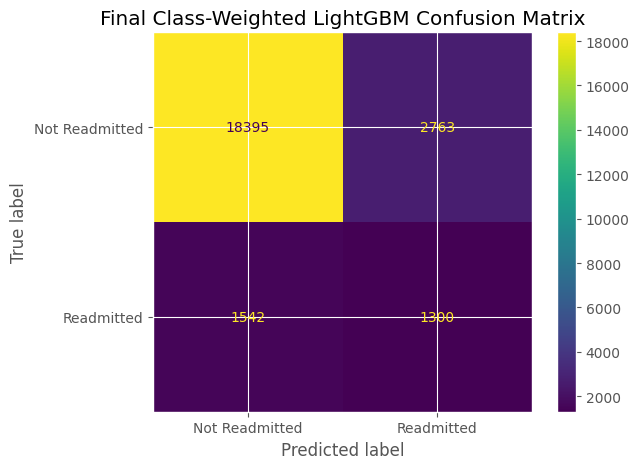

In [58]:
# ============================================================
# 16.4 CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    final_pred
)

print("Confusion Matrix")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Readmitted",
        "Readmitted"
    ]
).plot(
    values_format="d"
)

plt.title(
    "Final Class-Weighted LightGBM Confusion Matrix"
)

plt.tight_layout()
plt.show()

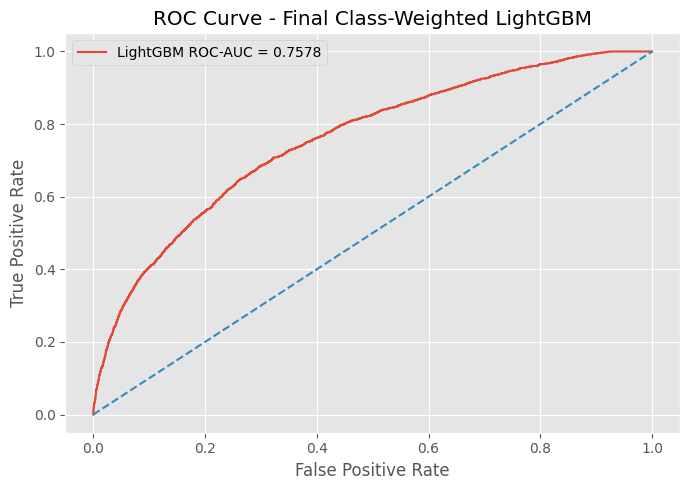

In [59]:
# ============================================================
# 16.5 ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_test,
    final_prob
)

final_roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC-AUC = {final_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Final Class-Weighted LightGBM"
)

plt.legend()

plt.tight_layout()
plt.show()

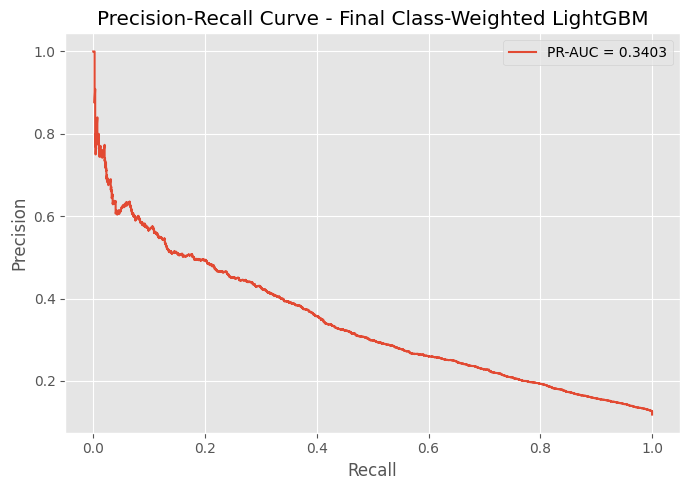

In [75]:
# ============================================================
# 16.6 PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    final_prob
)

final_pr_auc = average_precision_score(
    y_test,
    final_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"PR-AUC = {final_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Final Class-Weighted LightGBM"
)

plt.legend()

plt.tight_layout()
plt.show()

Top 15 Important Features


,Feature,Importance
0,creatinine,4311
1,haemoglobin,4226
2,systolic_bp,4065
3,age,3948
4,total_cost_inr,3717
5,out_of_pocket_inr,3273
6,hba1c,3010
7,beds,2922
8,govt_subsidy_inr,2828
9,los_days,2338


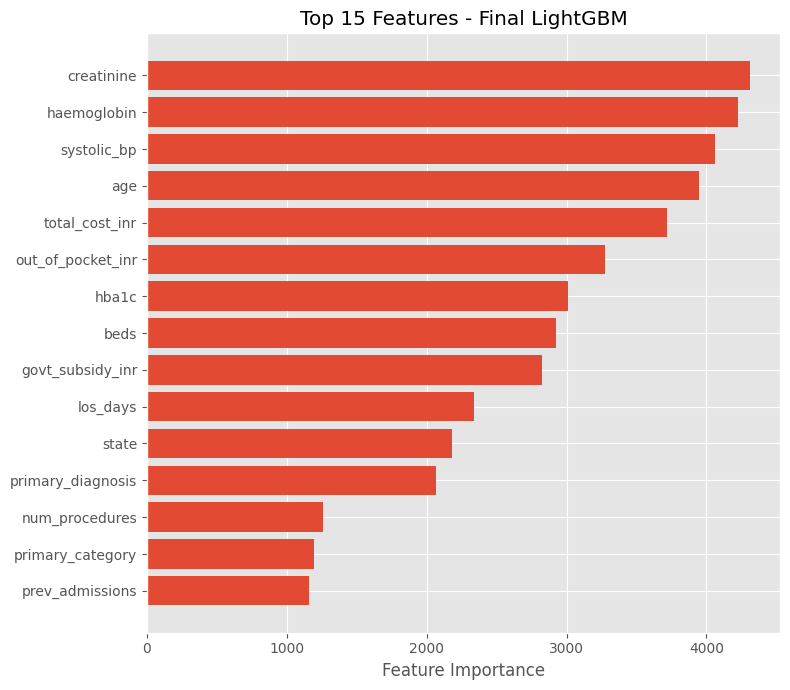

In [61]:
# ============================================================
# 16.7 LIGHTGBM FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 15 Important Features")

display(
    feature_importance.head(15)
)

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(8,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")

plt.title(
    "Top 15 Features - Final LightGBM"
)

plt.tight_layout()
plt.show()

## 17. Explainable Artificial Intelligence using SHAP

SHAP is applied to the final class-weighted LightGBM model to examine how individual input features influence model predictions.

Global SHAP analysis identifies features with stronger overall contributions across the selected test observations, while the waterfall plot provides a local explanation for an individual patient prediction.

SHAP values describe the behaviour of the trained machine-learning model and should not be interpreted as proof of clinical causation.

In [62]:
# ============================================================
# 17.1 SHAP INITIALIZATION
# ============================================================

import shap

print("Creating SHAP explainer...")

shap_explainer = shap.TreeExplainer(
    final_model
)

# Use a representative subset to reduce memory and runtime.
shap_sample = X_test.sample(
    n=min(3000, len(X_test)),
    random_state=42
)

shap_explanation = shap_explainer(
    shap_sample
)

print(
    "SHAP analysis samples:",
    shap_sample.shape[0]
)

Creating SHAP explainer...
SHAP analysis samples: 3000


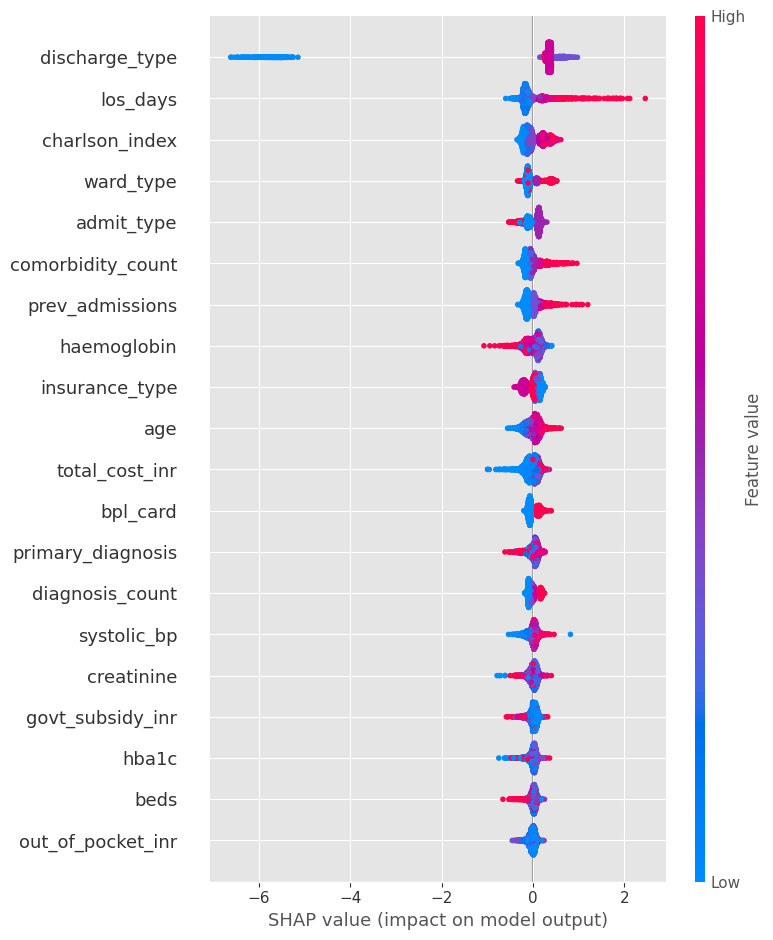

In [63]:
# ============================================================
# 17.2 SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_explanation,
    shap_sample,
    show=False
)

plt.tight_layout()
plt.show()

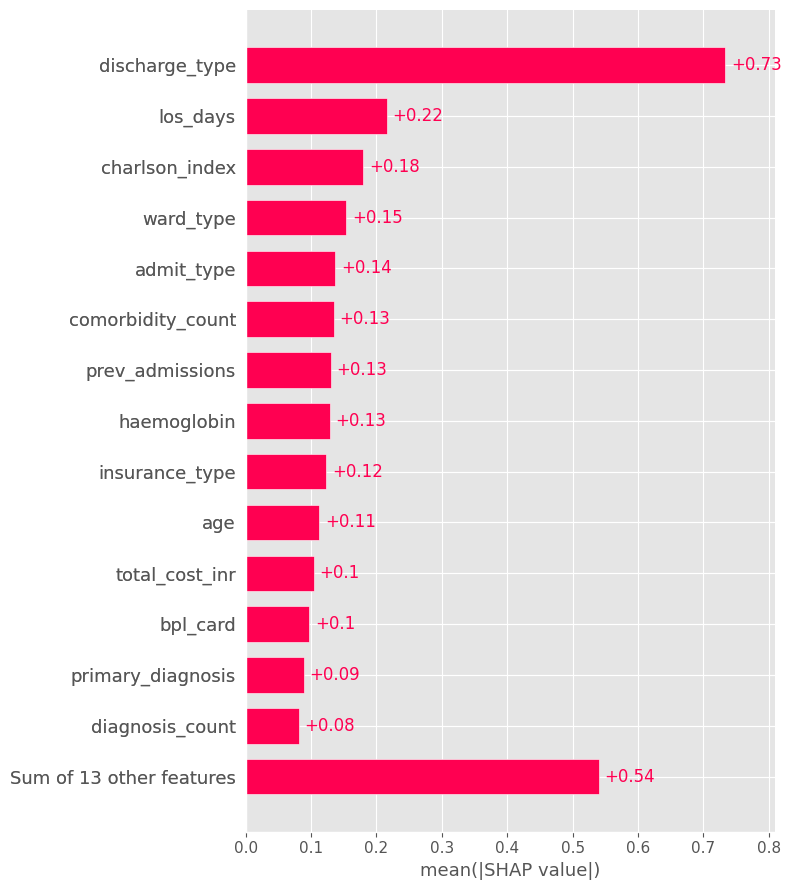

In [64]:
# ============================================================
# 17.3 SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

shap.plots.bar(
    shap_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

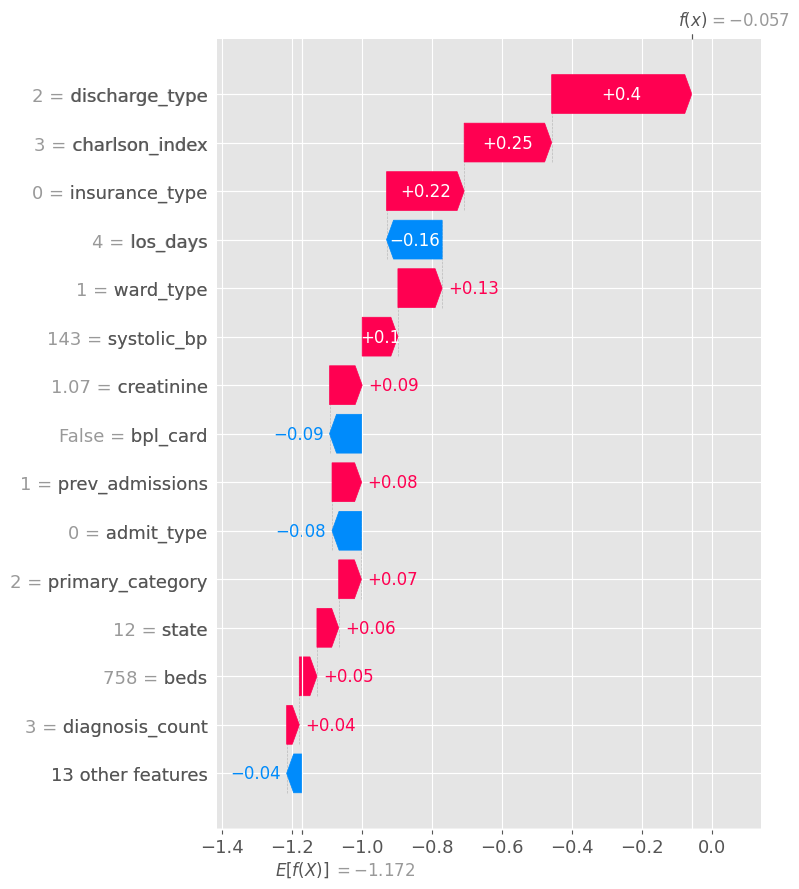

In [65]:
# ============================================================
# 17.4 INDIVIDUAL PATIENT SHAP WATERFALL
# ============================================================

patient_index = 0

shap.plots.waterfall(
    shap_explanation[
        patient_index
    ],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

## 18. Additional Experiment — Ensemble Learning

Additional ensemble-learning approaches are evaluated to determine whether combining multiple classifiers provides an improvement over the selected LightGBM model.

Voting and stacking are treated as supplementary experiments. The final CareWatch-AI deployment remains based on the class-weighted LightGBM model unless the ensemble results demonstrate a clearly superior balance of minority-class performance and overall discrimination.

In [66]:
# ============================================================
# 18.1 ENSEMBLE LEARNING
# ============================================================

from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier,
    RandomForestClassifier
)

from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


ensemble_estimators = [
    (
        "rf",
        RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            n_jobs=-1
        )
    ),
    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "lgb",
        LGBMClassifier(
            random_state=42,
            verbosity=-1
        )
    )
]

In [67]:
# ============================================================
# 18.2 SOFT VOTING CLASSIFIER
# ============================================================

voting_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft"
)

voting_model.fit(
    X_train_smote,
    y_train_smote
)

voting_prob = voting_model.predict_proba(
    X_test
)[:,1]

voting_pred = (
    voting_prob >= 0.50
).astype(int)

voting_results = {
    "Model":"Voting Ensemble",
    "Accuracy":accuracy_score(
        y_test,
        voting_pred
    ),
    "Precision":precision_score(
        y_test,
        voting_pred,
        zero_division=0
    ),
    "Recall":recall_score(
        y_test,
        voting_pred,
        zero_division=0
    ),
    "F1 Score":f1_score(
        y_test,
        voting_pred,
        zero_division=0
    ),
    "ROC-AUC":roc_auc_score(
        y_test,
        voting_prob
    ),
    "PR-AUC":average_precision_score(
        y_test,
        voting_prob
    )
}

print(voting_results)

{'Model': 'Voting Ensemble', 'Accuracy': 0.8762916666666667, 'Precision': 0.43419689119170984, 'Recall': 0.1474313863476425, 'F1 Score': 0.22012083004990807, 'ROC-AUC': 0.742448358947283, 'PR-AUC': 0.2989521662908328}


In [68]:
# ============================================================
# 18.3 STACKING CLASSIFIER
# ============================================================

stacking_model = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    stack_method="predict_proba",
    n_jobs=-1
)

stacking_model.fit(
    X_train_smote,
    y_train_smote
)

stacking_prob = stacking_model.predict_proba(
    X_test
)[:,1]

stacking_pred = (
    stacking_prob >= 0.50
).astype(int)

stacking_results = {
    "Model":"Stacking Ensemble",
    "Accuracy":accuracy_score(
        y_test,
        stacking_pred
    ),
    "Precision":precision_score(
        y_test,
        stacking_pred,
        zero_division=0
    ),
    "Recall":recall_score(
        y_test,
        stacking_pred,
        zero_division=0
    ),
    "F1 Score":f1_score(
        y_test,
        stacking_pred,
        zero_division=0
    ),
    "ROC-AUC":roc_auc_score(
        y_test,
        stacking_prob
    ),
    "PR-AUC":average_precision_score(
        y_test,
        stacking_prob
    )
}

print(stacking_results)

{'Model': 'Stacking Ensemble', 'Accuracy': 0.8601666666666666, 'Precision': 0.35414301929625425, 'Recall': 0.21956368754398312, 'F1 Score': 0.2710686359687228, 'ROC-AUC': 0.7350684095979987, 'PR-AUC': 0.27870050066026036}


In [70]:
# ============================================================
# 18.4 ENSEMBLE COMPARISON
# ============================================================

final_lightgbm_results = {
    "Model":"Final Class-Weighted LightGBM",
    "Accuracy":accuracy_score(
        y_test,
        final_pred
    ),
    "Precision":precision_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "Recall":recall_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "F1 Score":f1_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "ROC-AUC":roc_auc_score(
        y_test,
        final_prob
    ),
    "PR-AUC":average_precision_score(
        y_test,
        final_prob
    )
}

ensemble_comparison = pd.DataFrame([
    final_lightgbm_results,
    voting_results,
    stacking_results
])

display(
    ensemble_comparison.style.format({
        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "F1 Score":"{:.4f}",
        "ROC-AUC":"{:.4f}",
        "PR-AUC":"{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Final Class-Weighted LightGBM,0.8206,0.3200,0.4574,0.3765,0.7578,0.3403
1,Voting Ensemble,0.8763,0.4342,0.1474,0.2201,0.7424,0.2990
2,Stacking Ensemble,0.8602,0.3541,0.2196,0.2711,0.7351,0.2787


### Ensemble Learning Conclusion

Although the Voting and Stacking ensembles achieved higher overall accuracy than the selected LightGBM model, their recall and F1-score for the minority readmission class were considerably lower. Since CareWatch-AI aims to identify patients at risk of 30-day readmission, the Class-Weighted LightGBM model with a threshold of 0.55 was retained as the final deployment model because it provides a more appropriate balance between recall, F1-score, ROC-AUC and PR-AUC.

## 19. Model Saving and Deployment Preparation

The selected class-weighted LightGBM model and the feature-processing artifacts are serialized for integration with the CareWatch-AI Streamlit application.

The final binary operating threshold of 0.55 is saved separately so that the model-selection configuration remains reproducible. Numerical standardization is not applied to the final LightGBM model during inference because the final tree-based model was trained on the original unscaled feature representation.

In [71]:
# ============================================================
# 19.1 SAVE FINAL MODEL AND ARTIFACTS
# ============================================================

import joblib

joblib.dump(
    final_model,
    "carewatch_lightgbm_model.pkl"
)

joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

joblib.dump(
    final_threshold,
    "readmission_threshold.pkl"
)

# Retain scaler for scale-sensitive comparison models only.
joblib.dump(
    scaler,
    "scaler.pkl"
)

print(
    "Final model and deployment artifacts saved successfully."
)

Final model and deployment artifacts saved successfully.


In [72]:
# ============================================================
# 19.2 RELOAD FINAL MODEL
# ============================================================

loaded_model = joblib.load(
    "carewatch_lightgbm_model.pkl"
)

loaded_encoders = joblib.load(
    "label_encoders.pkl"
)

loaded_features = joblib.load(
    "feature_columns.pkl"
)

loaded_threshold = joblib.load(
    "readmission_threshold.pkl"
)

print("Model loaded successfully.")
print(
    "Number of features:",
    len(loaded_features)
)
print(
    "Decision threshold:",
    loaded_threshold
)

Model loaded successfully.
Number of features: 27
Decision threshold: 0.55


In [73]:
# ============================================================
# 19.3 DEPLOYMENT PREDICTION TEST
# ============================================================

sample_patient = X_test.iloc[[0]].copy()

sample_patient = sample_patient[
    loaded_features
]

sample_probability = float(
    loaded_model.predict_proba(
        sample_patient
    )[0][1]
)

sample_binary_prediction = int(
    sample_probability >= loaded_threshold
)

print("="*60)
print("DEPLOYMENT MODEL TEST")
print("="*60)

print(
    "Readmission Probability:",
    f"{sample_probability*100:.2f}%"
)

print(
    "Binary Prediction:",
    sample_binary_prediction
)

print(
    "Interpretation:",
    "Readmitted within 30 days"
    if sample_binary_prediction == 1
    else "Not readmitted within 30 days"
)

DEPLOYMENT MODEL TEST
Readmission Probability: 44.27%
Binary Prediction: 0
Interpretation: Not readmitted within 30 days


## 20. Final Project Statistics

The final project statistics summarize the dataset configuration, model-selection strategy and performance of the selected class-weighted LightGBM model.

The statistics are calculated directly from the executed notebook rather than being manually entered so that the reported values remain consistent with the final model run.

In [74]:
# ============================================================
# 20. FINAL PROJECT STATISTICS
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_prob
)

final_pr_auc = average_precision_score(
    y_test,
    final_prob
)

print("="*70)
print("CAREWATCH-AI — FINAL PROJECT STATISTICS")
print("="*70)

print(
    f"Dataset Size        : {len(X):,}"
)

print(
    f"Training Samples    : {len(X_train):,}"
)

print(
    f"Testing Samples     : {len(X_test):,}"
)

print(
    f"Number of Features  : {X.shape[1]}"
)

print(
    "Target Variable     : readmitted_30d"
)

print()

print(
    "Final Model         : Class-Weighted LightGBM"
)

print(
    f"Final Threshold     : {final_threshold:.2f}"
)

print()

print(
    f"Accuracy            : {final_accuracy:.4f}"
)

print(
    f"Precision           : {final_precision:.4f}"
)

print(
    f"Recall              : {final_recall:.4f}"
)

print(
    f"F1 Score            : {final_f1:.4f}"
)

print(
    f"ROC-AUC             : {final_roc_auc:.4f}"
)

print(
    f"PR-AUC              : {final_pr_auc:.4f}"
)

print("="*70)

CAREWATCH-AI — FINAL PROJECT STATISTICS
Dataset Size        : 120,000
Training Samples    : 96,000
Testing Samples     : 24,000
Number of Features  : 27
Target Variable     : readmitted_30d

Final Model         : Class-Weighted LightGBM
Final Threshold     : 0.55

Accuracy            : 0.8206
Precision           : 0.3200
Recall              : 0.4574
F1 Score            : 0.3765
ROC-AUC             : 0.7578
PR-AUC              : 0.3403
